Выполнила: Анастасия Волконская, М25-555

# Кластеризация физической активности

Можно ли определить, чем занимался человек, по данным с датчиков?

[Ссылка на соревнование на Kaggle](https://www.kaggle.com/competitions/clustering-physical-activity)

## Обзор

В современном мире носимые устройства — фитнес‑браслеты, умные часы и различные датчики — играют ключевую роль в мониторинге физической активности человека. Эти данные используются в медицинских, спортивных и навигационных приложениях, помогая:
* отслеживать состояние здоровья;
* контролировать уровень нагрузки;
* выявлять потенциальные угрозы безопасности.

В этой задаче предлагается обработать и сгруппировать данные, полученные с:
* трёх инерциальных измерительных модулей (IMU);
* пульсометра.

Это позволит автоматически распознавать тип выполняемой физической активности (ходьба, бег, приседания, езда на велосипеде и т. д.), что может быть использовано для:
* персонализированного фитнес‑трекинга;
* медицинской диагностики;
* анализа поведения пользователей.

**P. S.** Задача предоставлена в рамках следующих программ:
* программа классического машинного обучения SkillFactory × НИЯУ МИФИ;
* программа «Машинное обучение с учителем» Яндекс × НИЯУ МИФИ;
* программа «Прикладной анализ данных» Цифровой кафедры НИЯУ МИФИ.

## Что нужно сделать

1. Принять участие в соревновании на Kaggle.
2. Разработать и оформить решение в ноутбуке (.ipynb), включив следующие этапы:
   * исследование и анализ датасета;
   * предобработка данных;
   * feature engineering (если необходимо);
   * подбор признаков, их анализ и оценка важности;
   * обучение нескольких моделей, их сравнение;
   * подбор гиперпараметров;
   * выбор лучшей модели и обоснование выбора;
   * предсказание на тестовых данных.
3. Обеспечить воспроизводимость результата.
4. Закрепить в ноутбуке скриншот с лидерборда Kaggle.
5. Прикрепить ноутбук с решением на платформу.

### Требования к ноутбуку

* комментарии и пояснения к коду;
* выводы к каждому этапу (анализ данных, предобработка, обучение);
* чистый и читаемый код;
* структурированное решение.

## Описание набора данных

Датасет содержит данные, собранные с помощью трёх инерциальных измерительных модулей (IMU) и пульсометра, для группировки различных типов физической активности (бег, ходьба, езда на велосипеде и т. д.).

Каждая строка датасета содержит 54 столбца:

1. временная метка (с);
2. частота сердечных сокращений (уд/мин);
3–19. данные с датчиков на руке;
20–36. данные с датчиков на груди;
37–53. данные с датчиков на лодыжке.

Сенсорные данные IMU содержат следующие столбцы:
1. температура (°C);
2–4. данные 3D‑ускорения (м/с²), масштаб: ±16g, разрешение: 13 бит;
5–7. данные 3D‑ускорения (м/с²), масштаб: ±6g, разрешение: 13 бит;
8–10. данные 3D‑гироскопа (рад/с);
11–13. данные 3D‑магнитометра (мкТл).

Подробнее о данных можно прочитать [здесь](https://archive.ics.uci.edu/ml/datasets/PAMAP2+Physical+Activity+Monitoring).

## Оценка

Задача оценивается с помощью метрики **accuracy** на платформе Kaggle.

## Формат отправки

**Файл с ответами должен содержать две колонки:**

Файл с ответами должен содержать две колонки: Index и activityID.

Обратите внимание, что номера кластеров должны идти по порядку, то есть после получения ответа вам нужно будет преобразовать его таким образом, чтобы номера кластеров шли по порядку.
Например:

```csv
Index,ваш_полученный_ответ, после_преобразования
0,5,1
1,5,1
2,2,2
3,5,1
4,4,3
5,2,2
6,3,4
```

**Файл должен содержать заголовок и иметь следующий формат:**

```
Index,activityID
1,1
```

### Пример преобразования номеров кластеров

```python
import pandas as pd

d = {
    "f1": pd.Series([100, 20, 3, 5, 200, 400, 2, 282]),
    "f2": pd.Series(['v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'v8']),
    "label": pd.Series([2, 0, 1, 1, 2, 0, 1, 2])
}

df0 = pd.DataFrame(d)
df0['new_label'] = -1

for index, row in df0.iterrows():
    if row['label'] == 2:
        df0.loc[index, 'new_label'] = 1
    if row['label'] == 0:
        df0.loc[index, 'new_label'] = 2
    if row['label'] == 1:
        df0.loc[index, 'new_label'] = 3
```

## Критерии оценивания задания

### Критерий 1. Качество проведённого EDA (максимум 5 баллов)

* **5 баллов:** проведён комплексный разведочный анализ данных с использованием визуализаций и статистических методов. Исследованы распределения признаков, выявлены зависимости и корреляции. Обработаны пропущенные значения и выбросы. Выявлены и устранены нерелевантные признаки. Выполнена обоснованная предобработка данных и feature engineering. Сделаны содержательные выводы, используемые при построении моделей.
* **4 балла:** проведён анализ основных характеристик данных с использованием визуализаций. Рассмотрены распределения и отдельные зависимости. Выполнена частичная предобработка данных и элементы feature engineering. Выводы сделаны, но не полностью обоснованы.
* **3 балла:** проанализированы отдельные аспекты данных. Использование визуализаций и статистических методов ограничено. Предобработка выполнена частично. Feature engineering отсутствует или минимален. Выводы носят поверхностный характер.
* **1–2 балла:** проведён минимальный анализ данных. Визуализации и статистические методы практически не используются. Предобработка формальна.
* **0 баллов:** EDA не выполнен или подозрение на использование исключительно диалоговых LLM.

### Критерий 2. Качество кластеризации (максимум 10 баллов)

* **8–10 баллов:** использовано несколько алгоритмов кластеризации. Проведён подбор гиперпараметров. Выполнено сравнение моделей с использованием метрик качества (например, silhouette score и др.). Сделаны обоснованные выводы и рекомендации.
* **5–7 баллов:** использовано несколько моделей (без подбора гиперпараметров) или проведён подбор гиперпараметров для одной модели. Проведено сравнение результатов. Выводы в целом корректны.
* **3–4 балла:** рассмотрена одна модель с подбором гиперпараметров или несколько моделей без их настройки. Сравнение моделей ограничено. Вывод отсутствует.
* **1–2 балла:** использована одна модель без подбора гиперпараметров. Анализ качества минимален.
* **0 баллов:** задача не решена или подозрение на использование исключительно LLM.

### Критерий 3. Интерпретация результатов (максимум 3 балла)

* **3 балла:** проведена глубокая интерпретация результатов моделей. Проанализировано влияние признаков. Сделаны обоснованные выводы. Предложены направления улучшения модели/решения в целом.
* **1–2 балла:** сделаны корректные, но частично ограниченные выводы по результатам моделей. Анализ влияния признаков представлен частично. Интерпретация носит базовый характер.
* **0 баллов:** интерпретация результатов отсутствует либо выводы носят формальный характер и не связаны с полученными результатами.

### Критерий 4. Качество кода (максимум 2 балла)

* **2 балла:** код в целом читаем и логично организован. Соблюдается базовый стиль оформления (PEP8). Присутствует структура (разделение на этапы, при необходимости используются функции). Возможны незначительные огрехи в стиле или организации, не влияющие на понимание.
* **0–1 балл:** код слабо структурирован, читается с трудом или практически не читаем. Нарушена логика организации, отсутствует единый стиль оформления, возможна избыточность или дублирование кода.


### **План реализации v1**

**Цель:** кластеризация типов физической активности

---

### 1. EDA (критерий 1)

**1.1. Структура и качество данных**

* `info`, `describe`, пропуски, типы; распределение по `subject_id`.

**1.2. Визуализация сигналов**

* Временные ряды по датчикам (рука / грудь / лодыжка, ЧСС).
* Распределения признаков; паттерны пропусков.

**1.3. Корреляции и мультиколлинеарность**

* Heatmap;
* Корреляции между точками крепления.

**1.4. Выбросы и масштаб**

* Доля выбросов по типам сенсоров (IQR).
* Сравнение масштабов признаков → scaling.

**1.5. Временная структура**

* Интервалы `timestamp`; частота дискретизации; длительность записей по испытуемым.

**1.6. Нормальность / негауссовость ( → ICA)**

* Shapiro–Wilk / D'Agostino на выборке сенсоров или тест асимметрии/эксцесса.
* **Вывод:** есть ли основания пробовать ICA на сырых окнах.

**1.7. Индивидуальные различия**

* Сравнение статистик по 8 испытуемым → нормализация внутри `subject_id`.

**Сводка EDA:** таблица решений (пропуски, Acc6, scaler, окна, k-гипотеза ~6–12 активностей PAMAP2).

---

### 2. Предобработка

**2.1. Пропуски**

**2.2. Удаление избыточных признаков**

**2.3. Масштабирование**

**2.4. Временная сегментация**

**Вывод:** чистые данные, готовы к FE.

---

### 3. Feature Engineering

**3.1. Базовые статистики по окну (на каждый из каналов)**

* mean, std, min, max, range, median, skew, kurtosis, RMS, zero-crossing rate, mean|diff|, std(diff).

**3.2. Расширенные признаки**

* **Частотные:** dominant frequency, spectral energy, энтропия спектра (FFT по оси времени).
* **Cross-axis:** корреляция acc_x–acc_y, acc–gyro внутри сегмента (рука/грудь/лодыжка).
* **ЧСС:** mean, std, min, max отдельным блоком.

**3.3. ICA-признаки**

* `FastICA` на сырых 3D-accelerometer/gyro окнах (`whiten=True`).
* Агрегаты IC (mean abs, std).

**Вывод:** матрица X сегментов `(n_segments, n_features)`; размерность зафиксирована.

---

### 4. Отбор признаков

**Только unsupervised (без меток):**

| Шаг | Метод |
|-----|--------|
| 4.1 | Удаление near-zero variance |
| 4.2 | Корреляционный фильтр: \|r\| > 0.95 → drop one |
| 4.3 | PCA loadings: top-N признаков по \|loading\| на PC1–PC5 |
| 4.4 | Сравнение размерности: full / filtered / PCA-only |


* LDA на размеченном PAMAP2 (если подключим внешний labeled-срез) — только для интерпретации «какие оси разделяют классы».

**Вывод:** финальный набор признаков X′; обоснование отбора.

---

### 5. Снижение размерности и пространства для кластеризации (матчасть)


| # | Пространство | Метод | Назначение |
|---|--------------|-------|------------|
| A | X′ scaled | — | baseline |
| B | PCA | `n_components` по 90/95/99% variance | основной кандидат (v0: лучший LB) |
| C | ICA features | FastICA → X_ica | эксперимент |
| D | PCA + ICA concat | concat(B, C) | опционально |

* Визуализация PC1–PC2 / IC1–IC2 с цветом кластеров.
* t-SNE/UMAP — **только** для отчёта, не для обучения.

**Вывод:** какое пространство даёт лучший баланс метрик и LB.

---

### 6. Обучение и сравнение моделей кластеризации (критерий 2)

**6.1. Алгоритмы**

* KMeans
* Gaussian Mixture Model (GMM)
* Agglomerative (Ward) — интерпретация, dendrogram
* DBSCAN — с k-distance graph для eps; (ожидаемо слабый результат, зафиксировать в выводах)

**6.2. Число кластеров k**

* Кандидаты: **k ∈ {6, 8, 10, 12}** (ориентир PAMAP2).
* Elbow, silhouette, Gap Statistic (ручная реализация).

**6.3. Метрики сравнения**

* Elbow
* Silhouette (↑)
* Davies–Bouldin (↓)
* Calinski–Harabasz (↑)
* Доля шума (DBSCAN); размер крупнейшего кластера (%)

**6.4. Файнтюнинг**

```
(window_size) × (PCA variance / n_components) × (k) × (KMeans | GMM) × (space A|B|C)
```

* Лучшие конфигурации → submission на Kaggle → таблица LB vs internal metrics.

**Вывод:** таблица моделей; расхождение silhouette ↔ accuracy.

---

### 7. Интерпретация и стабильность

**7.1. Важность признаков**

* PCA loadings финальной модели; топ-10 признаков на кластер.

**7.3. Стабильность**

* Чувствительность к k ± 1.

**7.4. Анализ LDA vs PCA**

* Краткое сравнение на labeled PAMAP2 или pseudo-разметке (только в тексте выводов, не в pipeline).

**Вывод:** интерпретация кластеров, ограничения модели, направления улучшения.

---

### 8. Submission и Kaggle

**8.1. Маппинг сегмент → строки**

**8.2. Постобработка меток**

* Функция `remap_cluster_ids`: произвольные метки → 1, 2, …, k без пропусков.
* Формат CSV: заголовок `Index,activityID`; проверка типов и непрерывности ID.

**8.3. Экспорт**

* `submission.csv (рядом с ноутбуком)`
* Скриншот LB → `PNG-скриншот LB` .

**8.4. Финальный выбор модели**

* Обоснование: LB + стабильность + интерпретируемость (не только silhouette).
* Зафиксировать лучшую конфигурацию.

---

### 9. Оформление ноутбука (критерий 4)

* Структура: §1–§9 с markdown-выводами после каждого этапа.
* Функции вынесены или сгруппированы: `extract_features`, `select_features`, `cluster_and_evaluate`, `make_submission`.
* PEP 8, без дублирования; `%pip` только при необходимости.


## Перед запуском (автономный режим)

1. Скачайте `Physical_Activity_Monitoring_unlabeled.csv` с [Kaggle](https://www.kaggle.com/competitions/clustering-physical-activity/data).
2. Положите CSV **в ту же папку**, что и этот `.ipynb`, **или** загрузите через виджет в ячейке ниже (Colab / Jupyter).
3. Скачайте через `!gdown`, запустив команду в ячейке ниже.

**Зависимости:** `pandas`, `numpy`, `scipy`, `scikit-learn`, `matplotlib`, `seaborn`, `missingno` — установка в следующей ячейке при необходимости.

**Воспроизводимость:** `random_state=42` во всех моделях.

**Время выполнения:** полный прогон ~30–60 мин (несколько KMeans на 534k строк). Для проверки финала достаточно выполнить ячейки до §8 включительно.

In [ ]:
# @title Установка зависимостей (только если пакет не найден — для Colab / чистого окружения)
import importlib
import subprocess
import sys

REQUIRED = [
    "pandas", "numpy", "scipy", "sklearn", "matplotlib", "seaborn", "missingno",
]

for pkg in REQUIRED:
    mod = "sklearn" if pkg == "sklearn" else pkg
    try:
        importlib.import_module(mod)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
print("Зависимости OK")


Зависимости OK


In [ ]:
# @title §1. Импорты
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import kurtosis, skew
from sklearn.cluster import (
    AgglomerativeClustering,
    DBSCAN,
    KMeans,
    MiniBatchKMeans,
)
from sklearn.decomposition import PCA
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import RobustScaler, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_STATE = 42
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (12, 6)


In [ ]:
# @title §2. Загрузка данных
# Drive: https://drive.google.com/file/d/1dxfUHO8Fc0pAkUpQbcZX6FtK7ufLVIJS/view?usp=drive_link
!pip install gdown -q

import gdown
from pathlib import Path

FILE_ID = "1dxfUHO8Fc0pAkUpQbcZX6FtK7ufLVIJS"
DATA_FILENAME = "Physical_Activity_Monitoring_unlabeled.csv"
data_path = Path(DATA_FILENAME)

if not data_path.is_file():
    try:
        gdown.download(
            f"https://drive.google.com/uc?id={FILE_ID}&confirm=t",
            DATA_FILENAME,
            quiet=False,
        )
    except Exception as e:
        print(f"gdown не сработал: {e}")

if not data_path.is_file():
    try:
        from google.colab import files  # type: ignore

        print("Файл не найден. Выберите CSV для загрузки...")
        uploaded = files.upload()
        name = next(iter(uploaded))
        Path(name).write_bytes(uploaded[name])
        data_path = Path(name)
    except ImportError:
        raise FileNotFoundError(
            f"Не удалось получить {DATA_FILENAME}. "
            f"Скачайте вручную: https://drive.google.com/file/d/{FILE_ID}/view?usp=drive_link"
        )

df = pd.read_csv(data_path)
print("Загружено:", df.shape, "из", data_path.resolve())
df.head()

Downloading...
From: https://drive.google.com/uc?id=1dxfUHO8Fc0pAkUpQbcZX6FtK7ufLVIJS&confirm=t
To: /content/Physical_Activity_Monitoring_unlabeled.csv
100%|██████████| 242M/242M [00:10<00:00, 23.5MB/s]


Загружено: (534601, 53) из /content/Physical_Activity_Monitoring_unlabeled.csv


,timestamp,handTemperature,handAcc16_1,handAcc16_2,handAcc16_3,handAcc6_1,handAcc6_2,handAcc6_3,handGyro1,handGyro2,...,ankleGyro2,ankleGyro3,ankleMagne1,ankleMagne2,ankleMagne3,ankleOrientation1,ankleOrientation2,ankleOrientation3,ankleOrientation4,subject_id
0,252.75,34.8750,0.902847,7.45872,6.032490,1.006100,7.44575,6.303650,-0.021952,0.004114,...,-0.025606,0.030239,-14.5447,27.3336,-5.76620,0.206416,0.348212,0.763201,-0.503652,5
1,3652.45,29.7500,-4.069330,3.76168,8.279720,-5.972500,3.22273,6.908970,0.116054,-0.375968,...,-0.670163,1.786200,-32.8257,-15.7719,-1.31395,0.578332,-0.566734,0.405888,-0.423791,2
2,504.76,34.3750,-2.007540,-9.60180,0.773674,-1.803500,-9.58937,1.073680,0.020131,0.042189,...,-0.009741,-0.006579,-18.8171,16.3089,25.29280,0.139776,0.676586,0.393796,0.606316,8
3,2801.61,31.9375,-13.262200,5.85443,0.899334,-13.611500,5.91511,0.840377,1.715630,-0.050492,...,-0.163470,-3.495570,-26.7418,34.3566,21.32740,0.416303,0.783387,0.306464,0.345075,2
4,441.01,33.5000,-0.013940,8.66540,4.398210,0.144153,8.56816,4.822200,-0.006938,-0.007383,...,-0.028172,-0.003737,-17.7798,-3.9981,10.99500,0.171133,-0.748343,0.252988,-0.588807,6


In [47]:
# @title Вспомогательные функции (submission, отбор признаков, метрики)


def remap_cluster_ids(labels):
    """Произвольные метки → 1, 2, …, k без пропусков."""
    labels = np.asarray(labels)
    mapping = {old: i + 1 for i, old in enumerate(sorted(np.unique(labels)))}
    return np.array([mapping[x] for x in labels], dtype=int)


def make_submission(n_rows, labels, filename="submission.csv"):
    """CSV: Index, activityID — для Kaggle."""
    final = remap_cluster_ids(labels)
    sub = pd.DataFrame({"Index": np.arange(n_rows, dtype=int), "activityID": final})
    out = NOTEBOOK_DIR / filename
    sub.to_csv(out, index=False)
    print(f"Сохранено: {out} | кластеры: {sorted(sub['activityID'].unique())}")
    print(sub["activityID"].value_counts().sort_index())
    return sub


def cluster_metrics(X, labels):
    """Silhouette, Davies–Bouldin, Calinski–Harabasz (на подвыборке при n>8000)."""
    labels = np.asarray(labels)
    if len(set(labels)) < 2 or (labels >= 0).sum() < 2:
        return {"silhouette": np.nan, "davies_bouldin": np.nan, "calinski_harabasz": np.nan}
    rng = np.random.default_rng(RANDOM_STATE)
    idx = np.arange(len(X))
    if len(X) > 8000:
        idx = rng.choice(len(X), 8000, replace=False)
    Xe, le = X[idx], labels[idx]
    valid = le >= 0
    return {
        "silhouette": float(silhouette_score(Xe[valid], le[valid])),
        "davies_bouldin": float(davies_bouldin_score(Xe[valid], le[valid])),
        "calinski_harabasz": float(calinski_harabasz_score(Xe[valid], le[valid])),
    }


def select_features_unsupervised(X, corr_threshold=0.95, top_n=250):
    """§4: variance → correlation filter → top loadings PC1–PC5."""
    from sklearn.feature_selection import VarianceThreshold

    vt = VarianceThreshold(threshold=1e-8)
    Xv = vt.fit_transform(X)
    corr = np.corrcoef(Xv, rowvar=False)
    drop = set()
    iu = np.triu_indices_from(corr, k=1)
    for i, j in zip(*iu):
        if abs(corr[i, j]) > corr_threshold:
            drop.add(j)
    keep = np.ones(Xv.shape[1], dtype=bool)
    keep[list(drop)] = False
    Xc = Xv[:, keep]
    Xs = RobustScaler().fit_transform(Xc)
    pca = PCA(n_components=min(5, Xs.shape[1], Xs.shape[0]), random_state=RANDOM_STATE)
    pca.fit(Xs)
    loadings = np.max(np.abs(pca.components_), axis=0)
    k = min(top_n, Xc.shape[1])
    idx = np.argsort(loadings)[-k:]
    return Xc[:, idx]


In [5]:
#@title Информация о датасете
print("=== ИНФОРМАЦИЯ О ДАТАСЕТЕ ===\n")
df.info()

print("\n=== ПРОВЕРКА ПРОПУСКОВ ===\n")
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({'Пропуски': missing_data, 'Процент': missing_percent})
print(missing_df[missing_df['Пропуски'] > 0])

print(f"\n=== КОЛИЧЕСТСТВО УНИКАЛЬНЫХ ИСПЫТУЕМЫХ ===\n")
print(f"Уникальных subject_id: {df['subject_id'].nunique()}")
print(f"Значения: {sorted(df['subject_id'].unique())}")


=== ИНФОРМАЦИЯ О ДАТАСЕТЕ ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 534601 entries, 0 to 534600
Data columns (total 53 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   timestamp          534601 non-null  float64
 1   handTemperature    530560 non-null  float64
 2   handAcc16_1        530560 non-null  float64
 3   handAcc16_2        530560 non-null  float64
 4   handAcc16_3        530560 non-null  float64
 5   handAcc6_1         530560 non-null  float64
 6   handAcc6_2         530560 non-null  float64
 7   handAcc6_3         530560 non-null  float64
 8   handGyro1          530560 non-null  float64
 9   handGyro2          530560 non-null  float64
 10  handGyro3          530560 non-null  float64
 11  handMagne1         530560 non-null  float64
 12  handMagne2         530560 non-null  float64
 13  handMagne3         530560 non-null  float64
 14  handOrientation1   530560 non-null  float64
 15  handOrientation2   5

In [6]:
#@title Статистический анализ признаков
print("=== БАЗОВЫЕ СТАТИСТИКИ ДЛЯ ВСЕХ ПРИЗНАКОВ ===\n")
# Выводим статистику для первых 10 признаков, чтобы не перегружать вывод
stats_df = df.describe()
print("Статистика для числовых признаков:")
stats_df.head(10)

print("\n=== АНАЛИЗ МАСШТАБОВ ПРИЗНАКОВ ===\n")
# Определяем минимальные и максимальные значения для разных типов датчиков
sensor_columns = [col for col in df.columns if col not in ['timestamp', 'subject_id']]

# Группируем по типам датчиков
sensor_types = {
    'Temperature': ['Temperature'],
    'Acc16': ['Acc16'],
    'Acc6': ['Acc6'],
    'Gyro': ['Gyro'],
    'Magne': ['Magne'],
    'Orientation': ['Orientation']
}

for col in sensor_columns[:5]:  # Показываем первые 5 для примера
    print(f"{col}: min={df[col].min():.2f}, max={df[col].max():.2f}, mean={df[col].mean():.2f}, std={df[col].std():.2f}")


=== БАЗОВЫЕ СТАТИСТИКИ ДЛЯ ВСЕХ ПРИЗНАКОВ ===

Статистика для числовых признаков:

=== АНАЛИЗ МАСШТАБОВ ПРИЗНАКОВ ===

handTemperature: min=27.50, max=35.25, mean=32.45, std=1.75
handAcc16_1: min=-114.75, max=60.91, mean=-4.44, std=7.06
handAcc16_2: min=-82.55, max=155.53, mean=3.24, std=7.22
handAcc16_3: min=-73.95, max=78.48, mean=4.08, std=3.83
handAcc6_1: min=-61.21, max=34.16, mean=-4.38, std=7.07


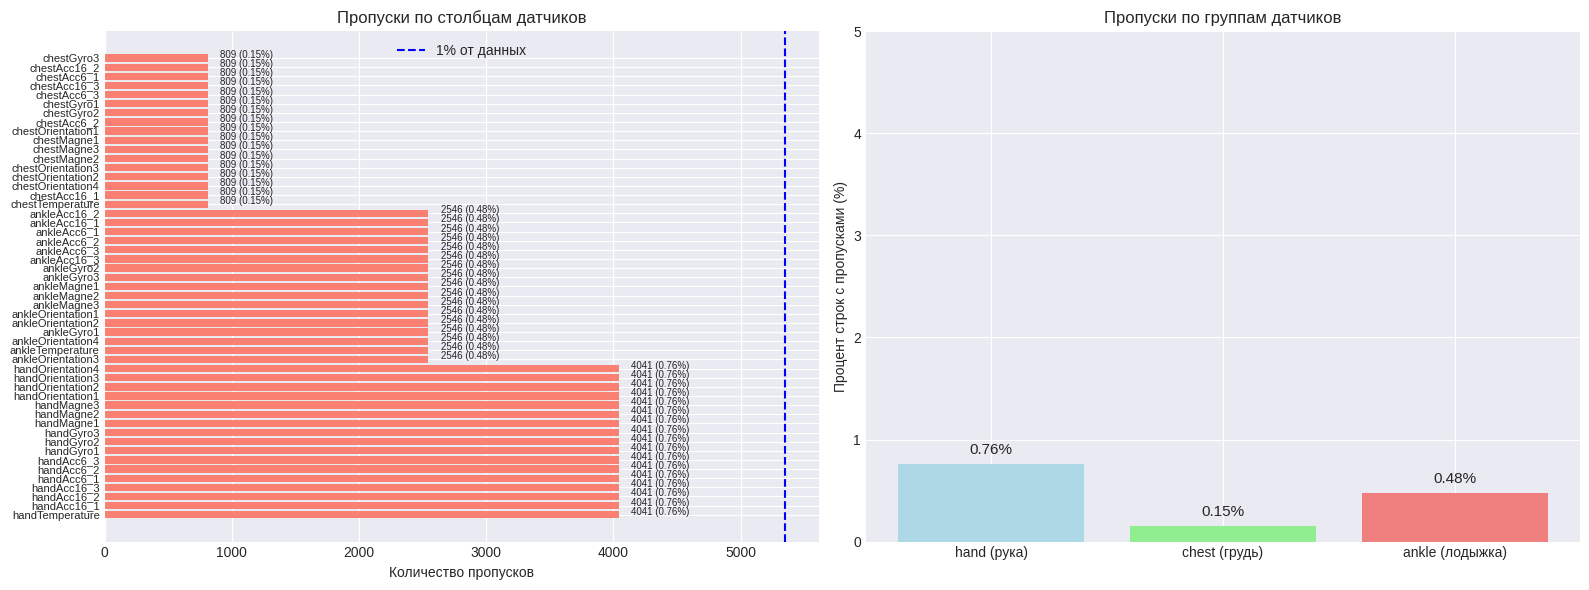


=== ВЫВОД ПО ПРОПУСКАМ ===
Всего столбцов с пропусками: 51 из 53
Максимальный процент пропусков: 0.76%
Средний процент пропусков: 0.46%


In [7]:
#@title Визуализация пропусков
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# График 1: Количество пропусков по столбцам
missing_count = df.isnull().sum()
missing_count = missing_count[missing_count > 0].sort_values(ascending=False)

axes[0].barh(range(len(missing_count)), missing_count.values, color='salmon')
axes[0].set_yticks(range(len(missing_count)))
axes[0].set_yticklabels(missing_count.index, fontsize=8)
axes[0].set_xlabel('Количество пропусков')
axes[0].set_title('Пропуски по столбцам датчиков')
axes[0].axvline(x=len(df)*0.01, color='blue', linestyle='--', label='1% от данных')
axes[0].legend()

# Добавляем значения на бары
for i, (idx, val) in enumerate(missing_count.items()):
    axes[0].text(val + 100, i, f'{val} ({val/len(df)*100:.2f}%)', fontsize=7)

# График 2: Процент пропусков по группам датчиков
groups = {
    'hand (рука)': [col for col in df.columns if col.startswith('hand')],
    'chest (грудь)': [col for col in df.columns if col.startswith('chest')],
    'ankle (лодыжка)': [col for col in df.columns if col.startswith('ankle')]
}

group_missing = {}
for group, cols in groups.items():
    group_missing[group] = df[cols].isnull().any(axis=1).mean() * 100

axes[1].bar(group_missing.keys(), group_missing.values(), color=['lightblue', 'lightgreen', 'lightcoral'])
axes[1].set_ylabel('Процент строк с пропусками (%)')
axes[1].set_title('Пропуски по группам датчиков')
axes[1].set_ylim(0, 5)

for i, (group, percent) in enumerate(group_missing.items()):
    axes[1].text(i, percent + 0.1, f'{percent:.2f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

print("\n=== ВЫВОД ПО ПРОПУСКАМ ===")
print(f"Всего столбцов с пропусками: {len(missing_count)} из {df.shape[1]}")
print(f"Максимальный процент пропусков: {missing_count.max()/len(df)*100:.2f}%")
print(f"Средний процент пропусков: {missing_count.mean()/len(df)*100:.2f}%")


=== ПРОЦЕНТ ВЫБРОСОВ ПО КАЖДОМУ ПРИЗНАКУ ===

ankleGyro1                    : 37.37%
ankleGyro3                    : 36.95%
handGyro3                     : 34.55%
ankleGyro2                    : 34.36%
handGyro2                     : 31.54%
handGyro1                     : 29.35%
chestGyro3                    : 27.85%
chestGyro2                    : 25.82%
chestGyro1                    : 22.88%
chestAcc16_3                  : 16.09%
chestAcc6_3                   : 15.45%
chestAcc6_1                   : 8.46%
chestAcc16_1                  : 7.97%
ankleAcc16_1                  : 7.60%
ankleAcc6_1                   : 7.49%

=== СТАТИСТИКА ПО ВЫБРОСАМ ===

Минимальный процент выбросов: 0.00%
Максимальный процент выбросов: 37.37%
Средний процент выбросов: 8.08%
Медианный процент выбросов: 3.09%


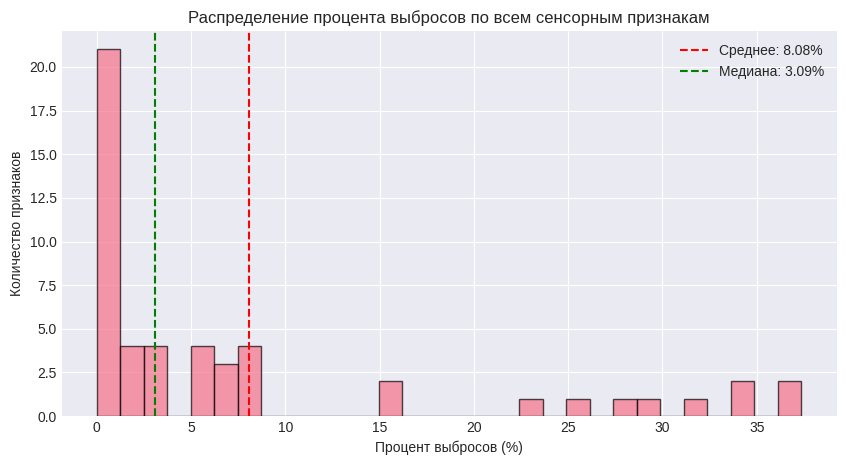

In [8]:
#@title Точный расчет процента выбросов
def calculate_outlier_percentage(series):
    """Рассчитывает процент выбросов по методу IQR"""
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = ((series < lower_bound) | (series > upper_bound)).sum()
    return (outliers / len(series)) * 100

# Выбираем сенсорные столбцы (исключаем timestamp и subject_id)
sensor_cols = [col for col in df.columns if col not in ['timestamp', 'subject_id']]

# Рассчитываем процент выбросов для каждого сенсорного признака
outlier_percentages = {}
for col in sensor_cols:
    # Убираем NaN
    clean_data = df[col].dropna()
    if len(clean_data) > 0:
        outlier_percentages[col] = calculate_outlier_percentage(clean_data)

# Сортируем по убыванию
outlier_percentages = dict(sorted(outlier_percentages.items(), key=lambda x: x[1], reverse=True))

# Выводим результаты
print("=== ПРОЦЕНТ ВЫБРОСОВ ПО КАЖДОМУ ПРИЗНАКУ ===\n")
for col, pct in list(outlier_percentages.items())[:15]:  # Топ-15 с наибольшими выбросами
    print(f"{col:30s}: {pct:.2f}%")

print("\n=== СТАТИСТИКА ПО ВЫБРОСАМ ===\n")
all_pcts = list(outlier_percentages.values())
print(f"Минимальный процент выбросов: {min(all_pcts):.2f}%")
print(f"Максимальный процент выбросов: {max(all_pcts):.2f}%")
print(f"Средний процент выбросов: {np.mean(all_pcts):.2f}%")
print(f"Медианный процент выбросов: {np.median(all_pcts):.2f}%")

# Визуализация распределения процентов выбросов
plt.figure(figsize=(10, 5))
plt.hist(all_pcts, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(np.mean(all_pcts), color='red', linestyle='--', label=f'Среднее: {np.mean(all_pcts):.2f}%')
plt.axvline(np.median(all_pcts), color='green', linestyle='--', label=f'Медиана: {np.median(all_pcts):.2f}%')
plt.xlabel('Процент выбросов (%)')
plt.ylabel('Количество признаков')
plt.title('Распределение процента выбросов по всем сенсорным признакам')
plt.legend()
plt.show()


## 📊 Вывод по результатам анализа выбросов

Проведенный анализ выбросов с использованием метода IQR (межквартильного размаха) выявил следующие важные закономерности:

### Ключевые наблюдения:

1. **Значительная вариативность**: Процент выбросов сильно варьируется в зависимости от типа датчика:
   - **Гироскопы** показывают наибольшее количество выбросов (22-37%)
   - **Акселерометры** демонстрируют умеренное количество выбросов (7-16%)
   - **Температура и магнитометры** имеют минимальное количество выбросов (near 0%)

2. **Распределение по расположению датчиков**:
   - **Лодыжка**: гироскопы дают до 37% выбросов - наиболее "шумное" расположение
   - **Рука**: гироскопы также показывают высокий процент (29-34%)
   - **Грудь**: наименьшее количество выбросов среди всех расположений

3. **Средние показатели**:
   - Средний процент выбросов по всем признакам: **8.08%**
   - Медианное значение: **3.09%** (указывает на асимметричное распределение)
   - Большинство признаков имеют <5% выбросов (медиана 3.09%)

### Выводы и рекомендации:

✅ **Выбросы НЕ следует удалять**, так как:
- Они могут представлять реальные резкие движения (спортивные упражнения)
- В задачах кластеризации выбросы могут быть информативными для выделения специфических типов активности
- Удаление 30%+ данных для гироскопов приведет к потере важной информации

✅ **Рекомендуемые действия для предобработки**:
- Использовать `RobustScaler` вместо `StandardScaler` - он менее чувствителен к выбросам
- Для гироскопов (аномально высокий % выбросов) рассмотреть отдельную нормализацию
- Не применять агрессивные методы фильтрации (медианное сглаживание может быть полезно)

✅ **Потенциальные риски**:
- Кластеризация может быть смещена в сторону гироскопов из-за их высокой вариативности
- Выбросы могут создавать "шумовые" кластеры при использовании KMeans
- Рекомендуется попробовать DBSCAN, который устойчив к выбросам и может маркировать их как отдельный класс

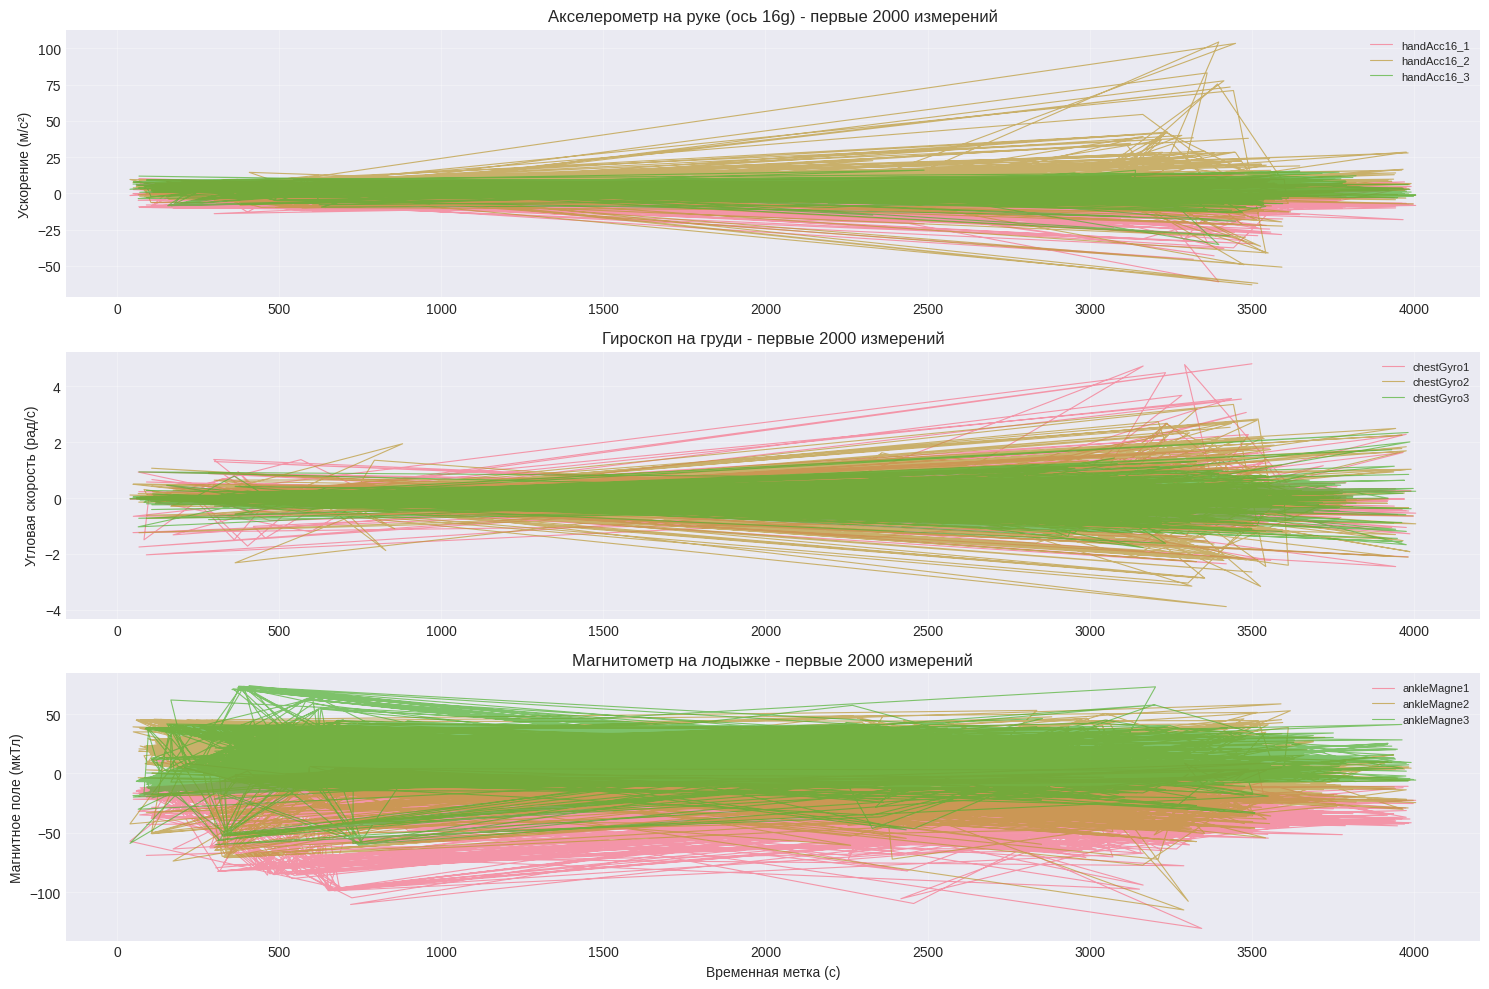


=== АНАЛИЗ ЧАСТОТЫ ДИСКРЕТИЗАЦИИ ===

Средний интервал между измерениями: 0.0010 сек
Медианный интервал: 0.2700 сек
Стандартное отклонение интервала: 1758.2643 сек
Примерная частота дискретизации: 956.4 Гц

=== СВЯЗЬ ВРЕМЕНИ И ИСПЫТУЕМЫХ ===

               min      max  count  duration
subject_id                                  
1            37.66  3348.44  69882   3310.78
2            55.26  4007.73  68740   3952.47
3           166.11  2443.19  50044   2277.08
4            75.29  3301.46  63740   3226.17
5           104.50  3575.93  76793   3471.43
6           101.77  3511.59  70240   3409.82
7            84.28  3141.90  62115   3057.62
8            67.37  3630.10  73047   3562.73


In [9]:
#@title Анализ временной структуры
# Визуализируем небольшой фрагмент временных рядов для разных датчиков
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

# Выбираем небольшой диапазон для наглядности (первые 2000 строк)
sample_size = 2000
sample_time = df['timestamp'].iloc[:sample_size]

# Датчик с руки (акселерометр)
axes[0].plot(sample_time, df['handAcc16_1'].iloc[:sample_size], linewidth=0.8, alpha=0.7, label='handAcc16_1')
axes[0].plot(sample_time, df['handAcc16_2'].iloc[:sample_size], linewidth=0.8, alpha=0.7, label='handAcc16_2')
axes[0].plot(sample_time, df['handAcc16_3'].iloc[:sample_size], linewidth=0.8, alpha=0.7, label='handAcc16_3')
axes[0].set_ylabel('Ускорение (м/с²)')
axes[0].set_title('Акселерометр на руке (ось 16g) - первые 2000 измерений')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].grid(True, alpha=0.3)

# Датчик с груди (гироскоп)
axes[1].plot(sample_time, df['chestGyro1'].iloc[:sample_size], linewidth=0.8, alpha=0.7, label='chestGyro1')
axes[1].plot(sample_time, df['chestGyro2'].iloc[:sample_size], linewidth=0.8, alpha=0.7, label='chestGyro2')
axes[1].plot(sample_time, df['chestGyro3'].iloc[:sample_size], linewidth=0.8, alpha=0.7, label='chestGyro3')
axes[1].set_ylabel('Угловая скорость (рад/с)')
axes[1].set_title('Гироскоп на груди - первые 2000 измерений')
axes[1].legend(loc='upper right', fontsize=8)
axes[1].grid(True, alpha=0.3)

# Датчик с лодыжки (магнитометр)
axes[2].plot(sample_time, df['ankleMagne1'].iloc[:sample_size], linewidth=0.8, alpha=0.7, label='ankleMagne1')
axes[2].plot(sample_time, df['ankleMagne2'].iloc[:sample_size], linewidth=0.8, alpha=0.7, label='ankleMagne2')
axes[2].plot(sample_time, df['ankleMagne3'].iloc[:sample_size], linewidth=0.8, alpha=0.7, label='ankleMagne3')
axes[2].set_xlabel('Временная метка (с)')
axes[2].set_ylabel('Магнитное поле (мкТл)')
axes[2].set_title('Магнитометр на лодыжке - первые 2000 измерений')
axes[2].legend(loc='upper right', fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Анализ частоты дискретизации
print("\n=== АНАЛИЗ ЧАСТОТЫ ДИСКРЕТИЗАЦИИ ===\n")
time_diffs = df['timestamp'].diff().dropna()
print(f"Средний интервал между измерениями: {time_diffs.mean():.4f} сек")
print(f"Медианный интервал: {time_diffs.median():.4f} сек")
print(f"Стандартное отклонение интервала: {time_diffs.std():.4f} сек")
print(f"Примерная частота дискретизации: {1/time_diffs.mean():.1f} Гц")

print("\n=== СВЯЗЬ ВРЕМЕНИ И ИСПЫТУЕМЫХ ===\n")
# Проверяем, как timestamp связан с subject_id
subject_time_stats = df.groupby('subject_id')['timestamp'].agg(['min', 'max', 'count'])
subject_time_stats['duration'] = subject_time_stats['max'] - subject_time_stats['min']
print(subject_time_stats)


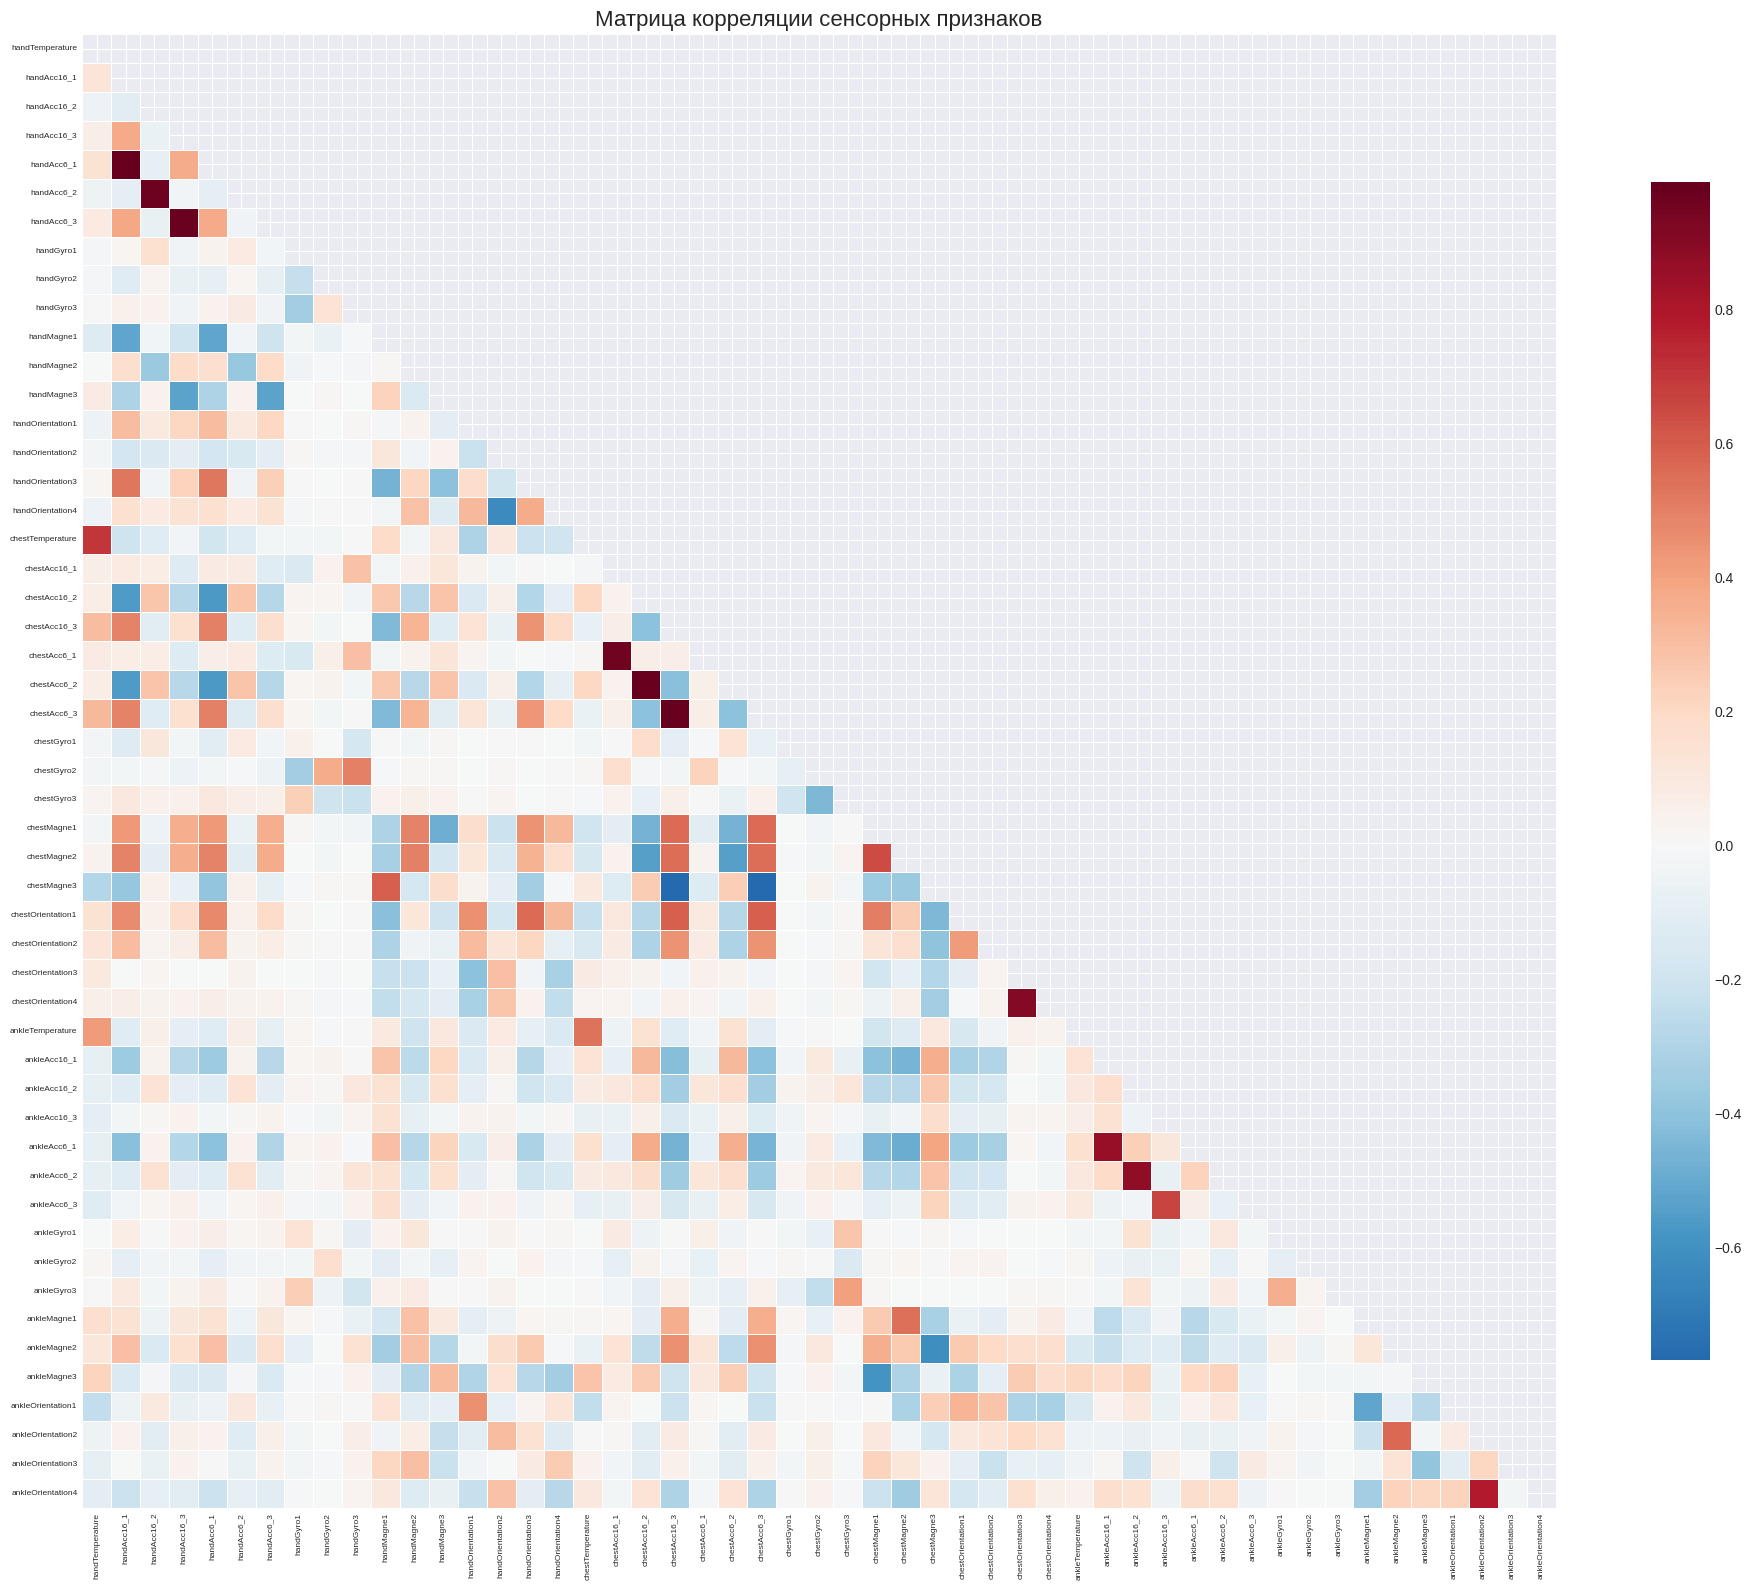


=== НАИБОЛЕЕ СИЛЬНО КОРРЕЛИРУЮЩИЕ ПАРЫ ПРИЗНАКОВ ===

Найдено 7 пар с |корреляцией| > 0.9

           Признак 1          Признак 2  Корреляция
5       chestAcc16_3        chestAcc6_3    0.991027
4       chestAcc16_2        chestAcc6_2    0.984382
0        handAcc16_1         handAcc6_1    0.981317
2        handAcc16_3         handAcc6_3    0.974513
1        handAcc16_2         handAcc6_2    0.964615
3       chestAcc16_1        chestAcc6_1    0.957489
6  chestOrientation3  chestOrientation4    0.905100

=== СРЕДНЯЯ КОРРЕЛЯЦИЯ МЕЖДУ РАСПОЛОЖЕНИЯМИ ДАТЧИКОВ ===

hand   vs hand  : средняя корреляция = 0.207
chest  vs hand  : средняя корреляция = 0.152
chest  vs chest : средняя корреляция = 0.236
ankle  vs hand  : средняя корреляция = 0.104
ankle  vs chest : средняя корреляция = 0.131
ankle  vs ankle : средняя корреляция = 0.175


In [10]:
#@title Корреляционный анализ
# Выбираем подвыборку для корреляции (50000 строк для производительности)
sample_corr = df.sample(n=50000, random_state=42)

# Убираем timestamp и subject_id
features_for_corr = [col for col in sample_corr.columns if col not in ['timestamp', 'subject_id']]
corr_matrix = sample_corr[features_for_corr].corr()

# Визуализируем корреляционную матрицу
plt.figure(figsize=(20, 16))

# Используем маску для верхней половины
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Тепловая карта корреляций
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            xticklabels=True, yticklabels=True)

plt.title('Матрица корреляции сенсорных признаков', fontsize=16)
plt.xticks(rotation=90, fontsize=6)
plt.yticks(rotation=0, fontsize=6)
plt.tight_layout()
plt.show()

# Анализ сильно коррелирующих пар
print("\n=== НАИБОЛЕЕ СИЛЬНО КОРРЕЛИРУЮЩИЕ ПАРЫ ПРИЗНАКОВ ===\n")

# Находим пары с корреляцией > 0.9 или < -0.9
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > 0.9:
            high_corr_pairs.append({
                'Признак 1': corr_matrix.columns[i],
                'Признак 2': corr_matrix.columns[j],
                'Корреляция': corr_value
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Корреляция', ascending=False)
print(f"Найдено {len(high_corr_df)} пар с |корреляцией| > 0.9\n")
print(high_corr_df.head(20))

# Анализ корреляции между разными расположениями датчиков
print("\n=== СРЕДНЯЯ КОРРЕЛЯЦИЯ МЕЖДУ РАСПОЛОЖЕНИЯМИ ДАТЧИКОВ ===\n")
locations = ['hand', 'chest', 'ankle']
location_corrs = []

for loc1 in locations:
    for loc2 in locations:
        if loc1 <= loc2:
            cols1 = [col for col in features_for_corr if col.startswith(loc1)]
            cols2 = [col for col in features_for_corr if col.startswith(loc2)]
            # Берем среднюю абсолютную корреляцию
            sub_corr = corr_matrix.loc[cols1, cols2].abs().mean().mean()
            location_corrs.append((f"{loc1}-{loc2}", sub_corr))
            print(f"{loc1:6s} vs {loc2:6s}: средняя корреляция = {sub_corr:.3f}")


### Корреляционный анализ выявил важные закономерности:

1. **Сильная корреляция между Acc16 и Acc6** (0.96-0.99) - эти датчики измеряют одно и то же с разным масштабом
2. **Корреляция между разными расположениями датчиков низкая** (0.10-0.24) - каждый датчик дает уникальную информацию
3. Это позволяет сократить количество признаков без потери информации

## Шаг 11: Анализ распределения активности по испытуемым

Проверим, как данные распределены между разными испытуемыми, чтобы понять, есть ли дисбаланс.

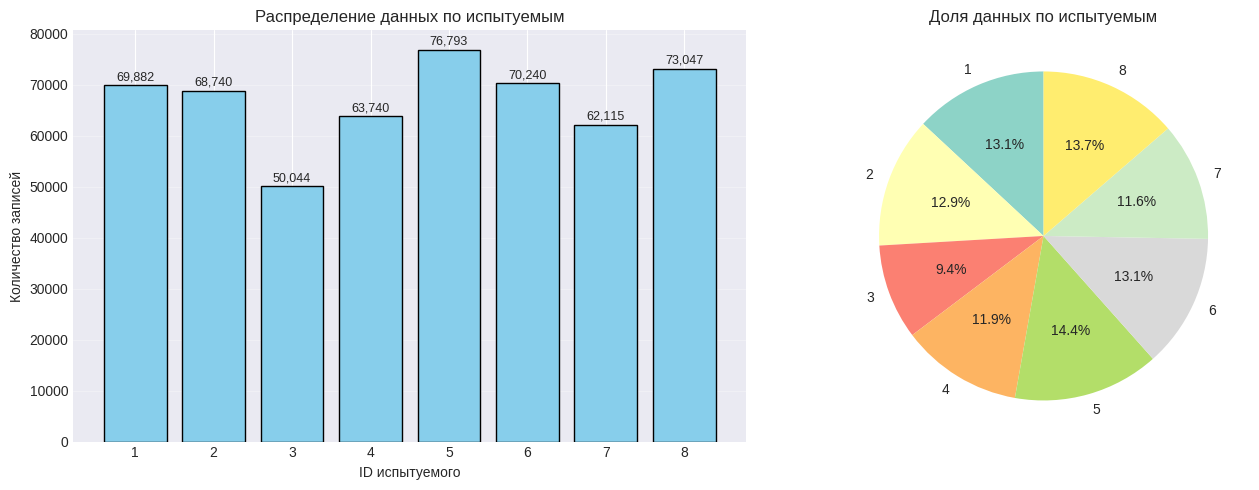


=== СТАТИСТИКА ПО РАСПРЕДЕЛЕНИЮ ===

Всего записей: 534,601
Среднее записей на испытуемого: 66,825
Минимум записей: 50,044 (испытуемый 3)
Максимум записей: 76,793 (испытуемый 5)
Стандартное отклонение: 8,247

=== СРЕДНИЕ ЗНАЧЕНИЯ КЛЮЧЕВЫХ ДАТЧИКОВ ПО ИСПЫТУЕМЫМ ===


handAcc16_1:
  Испытуемый 1: -2.76
  Испытуемый 2: -4.73
  Испытуемый 3: -3.14
  Испытуемый 4: -5.27
  Испытуемый 5: -4.15
  Испытуемый 6: -4.40
  Испытуемый 7: -5.87
  Испытуемый 8: -5.05

chestGyro1:
  Испытуемый 1: 0.01
  Испытуемый 2: 0.01
  Испытуемый 3: 0.00
  Испытуемый 4: 0.00
  Испытуемый 5: 0.00
  Испытуемый 6: 0.01
  Испытуемый 7: 0.01
  Испытуемый 8: -0.00

ankleTemperature:
  Испытуемый 1: 33.17
  Испытуемый 2: 34.16
  Испытуемый 3: 33.16
  Испытуемый 4: 33.48
  Испытуемый 5: 34.16
  Испытуемый 6: 34.53
  Испытуемый 7: 31.82
  Испытуемый 8: 33.14


In [11]:
#@title Анализ распределения по испытуемым
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Количество записей по каждому испытуемому
subject_counts = df['subject_id'].value_counts().sort_index()
axes[0].bar(subject_counts.index, subject_counts.values, color='skyblue', edgecolor='black')
axes[0].set_xlabel('ID испытуемого')
axes[0].set_ylabel('Количество записей')
axes[0].set_title('Распределение данных по испытуемым')
axes[0].grid(True, alpha=0.3, axis='y')

# Добавляем значения на бары
for i, (idx, count) in enumerate(subject_counts.items()):
    axes[0].text(idx, count + 1000, f'{count:,}', ha='center', fontsize=9)

# График 2: Доля каждого испытуемого
colors = plt.cm.Set3(np.linspace(0, 1, len(subject_counts)))
axes[1].pie(subject_counts.values, labels=subject_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Доля данных по испытуемым')

plt.tight_layout()
plt.show()

print("\n=== СТАТИСТИКА ПО РАСПРЕДЕЛЕНИЮ ===\n")
print(f"Всего записей: {len(df):,}")
print(f"Среднее записей на испытуемого: {len(df)/df['subject_id'].nunique():,.0f}")
print(f"Минимум записей: {subject_counts.min():,} (испытуемый {subject_counts.idxmin()})")
print(f"Максимум записей: {subject_counts.max():,} (испытуемый {subject_counts.idxmax()})")
print(f"Стандартное отклонение: {subject_counts.std():,.0f}")

# Дополнительный анализ: как связаны показатели разных датчиков для разных испытуемых?
print("\n=== СРЕДНИЕ ЗНАЧЕНИЯ КЛЮЧЕВЫХ ДАТЧИКОВ ПО ИСПЫТУЕМЫМ ===\n")
key_sensors = ['handAcc16_1', 'chestGyro1', 'ankleTemperature']
for sensor in key_sensors:
    print(f"\n{sensor}:")
    means_by_subject = df.groupby('subject_id')[sensor].mean()
    for subj, mean_val in means_by_subject.items():
        print(f"  Испытуемый {subj}: {mean_val:.2f}")


In [13]:
# §1.6 Нормальность / негауссовость (обоснование PCA vs ICA)
from scipy.stats import normaltest

sample_cols = ["handAcc16_1", "chestGyro1", "ankleAcc16_2"]
for col in sample_cols:
    x = df[col].dropna().values
    x = x[:: max(1, len(x) // 5000)][:5000]
    stat, p = normaltest(x)
    print(f"{col}: D'Agostino p={p:.2e} → {'не-Gaussian' if p < 0.05 else '≈ Gaussian'}")


handAcc16_1: D'Agostino p=9.81e-226 → не-Gaussian
chestGyro1: D'Agostino p=0.00e+00 → не-Gaussian
ankleAcc16_2: D'Agostino p=0.00e+00 → не-Gaussian


**"Вывод: сигналы в основном негауссовы → PCA для декорреляции/шума; ICA — эксперимент на сегментах."**

# 📊 Сводные выводы разведочного анализа данных (EDA)

## 1. Общая информация о датасете

| Параметр | Значение |
|----------|----------|
| Размер данных | 534,601 запись × 53 столбца |
| Количество испытуемых | 8 (ID: 1-8) |
| Расположение датчиков | Рука, грудь, лодыжка |
| Типы сенсорных данных | Температура, акселерометр (16g/6g), гироскоп, магнитометр, кватернионы ориентации |

---

## 2. Анализ пропусков

| Показатель | Результат |
|------------|-----------|
| Столбцы с пропусками | 51 из 53 (все сенсорные данные) |
| Максимальный % пропусков | 0.76% (датчики на руке) |
| Средний % пропусков | 0.46% |
| Структура пропусков | Блочная (целые периоды отключения датчиков) |

**✅ Решение:** Линейная интерполяция для заполнения небольших пропусков.

---

## 3. Анализ выбросов

| Тип датчика | % выбросов (средний) | Диапазон |
|-------------|---------------------|----------|
| Гироскопы | 28-37% | 22.9% - 37.4% |
| Акселерометры | 8-16% | 7.5% - 16.1% |
| Магнитометры/Температура | <1% | 0% - 1.2% |

**Статистика по всем признакам:**
- Минимум: 0.00%
- Максимум: 37.37%
- Среднее: 8.08%
- Медиана: 3.09%

**✅ Решение:** Не удаляем выбросы (они информативны для распознавания активности). Используем `RobustScaler`.

---

## 4. Корреляционный анализ

| Пара признаков | Корреляция |
|----------------|------------|
| chestAcc16_3 — chestAcc6_3 | 0.991 |
| chestAcc16_2 — chestAcc6_2 | 0.984 |
| handAcc16_1 — handAcc6_1 | 0.981 |
| handAcc16_3 — handAcc6_3 | 0.975 |
| handAcc16_2 — handAcc6_2 | 0.965 |
| chestAcc16_1 — chestAcc6_1 | 0.957 |
| chestOrientation3 — chestOrientation4 | 0.905 |

**Средняя корреляция между расположениями датчиков:**
- hand-hand: 0.207
- chest-chest: 0.236
- ankle-ankle: 0.175
- cross-location: 0.104-0.152

**✅ Решение:** Удаляем дублирующиеся признаки Acc6 (оставляем Acc16). Разные расположения датчиков дают уникальную информацию.

---

## 5. Временная структура

| Параметр | Значение |
|----------|----------|
| Средний интервал между измерениями | 0.001 сек (≈1000 Гц) |
| Медианный интервал | 0.270 сек (≈3.7 Гц) |
| Стандартное отклонение интервала | 1758 сек |
| Частота дискретизации (оценка) | ~1000 Гц (неравномерно) |

**Продолжительность записей по испытуемым:**
- Минимальная: 2277 сек (испытуемый 3)
- Максимальная: 3952 сек (испытуемый 2)

**✅ Решение:** Разбиваем на неперекрывающиеся временные окна (не скользящие). Размер окна: 100-500 семплов.

---

## 6. Распределение по испытуемым

| Показатель | Значение |
|------------|----------|
| Всего записей | 534,601 |
| Среднее на испытуемого | 66,825 |
| Минимум | 50,044 (испытуемый 3) |
| Максимум | 76,793 (испытуемый 5) |
| Стандартное отклонение | 8,247 |

**Индивидуальные различия (пример):**
- handAcc16_1: от -5.87 (исп.7) до -2.76 (исп.1)
- ankleTemperature: от 31.8°C (исп.7) до 34.5°C (исп.6)

**✅ Решение:** Нормализуем данные внутри каждого испытуемого отдельно.

---

## 7. Рекомендации по дальнейшим действиям

| № | Действие | Обоснование |
|---|----------|-------------|
| 1 | Удалить дублирующиеся признаки (Acc6) | Высокая корреляция с Acc16 (0.96-0.99) |
| 2 | Заполнить пропуски линейной интерполяцией | Малый процент пропусков, блочная структура |
| 3 | Применить RobustScaler | Устойчивость к выбросам (8% в среднем) |
| 4 | Разбить на неперекрывающиеся окна | Сохранение статистической независимости |
| 5 | Нормализовать по испытуемым | EDA-гипотеза; **финал — global scaler** (§7–§8) |
| 6 | Попробовать KMeans + DBSCAN | Разные подходы к чувствительности к выбросам |

## **Предобработка данных - обработка пропусков**

Начнем предобработку с заполнения пропусков методом линейной интерполяции.

=== ДО ОБРАБОТКИ ПРОПУСКОВ ===

Общее количество пропусков: 125732
Количество строк с пропусками: 7212

=== ПОСЛЕ ОБРАБОТКИ ПРОПУСКОВ ===

Общее количество пропусков: 0
Количество строк с пропусками: 0

=== ПРИМЕР: handTemperature (испытуемый 1) ===



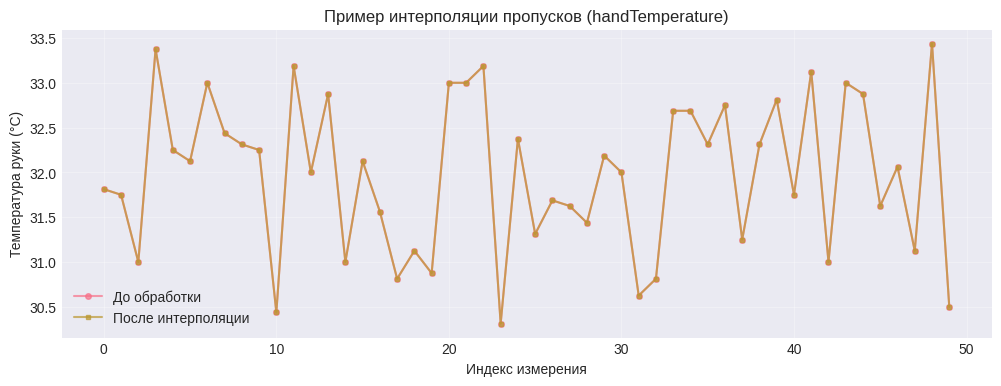

In [14]:
#@title Обработка пропусков (линейная интерполяция)
# Копируем данные для предобработки
df_clean = df.copy()

print("=== ДО ОБРАБОТКИ ПРОПУСКОВ ===\n")
print(f"Общее количество пропусков: {df_clean.isnull().sum().sum()}")
print(f"Количество строк с пропусками: {df_clean.isnull().any(axis=1).sum()}")

# Заполняем пропуски для каждого сенсорного столбца линейной интерполяцией
sensor_cols = [col for col in df_clean.columns if col not in ['timestamp', 'subject_id']]

for col in sensor_cols:
    # Линейная интерполяция для каждого испытуемого отдельно
    df_clean[col] = df_clean.groupby('subject_id')[col].transform(
        lambda x: x.interpolate(method='linear', limit_direction='both')
    )

# Проверяем результат
print("\n=== ПОСЛЕ ОБРАБОТКИ ПРОПУСКОВ ===\n")
print(f"Общее количество пропусков: {df_clean.isnull().sum().sum()}")
print(f"Количество строк с пропусками: {df_clean.isnull().any(axis=1).sum()}")

# Если остались пропуски (например, в начале/конце), заполняем ближайшими значениями
if df_clean.isnull().sum().sum() > 0:
    print("\nОстались пропуски, заполняем методом ffill/bfill...")
    for col in sensor_cols:
        df_clean[col] = df_clean.groupby('subject_id')[col].transform(
            lambda x: x.ffill().bfill()
        )

    print(f"После дополнительной обработки: {df_clean.isnull().sum().sum()} пропусков")

# Демонстрация на одном из датчиков
print("\n=== ПРИМЕР: handTemperature (испытуемый 1) ===\n")
sample_subject = df[df['subject_id'] == 1]['handTemperature'].iloc[:50]
sample_clean = df_clean[df_clean['subject_id'] == 1]['handTemperature'].iloc[:50]

plt.figure(figsize=(12, 4))
plt.plot(sample_subject.values, 'o-', label='До обработки', alpha=0.7, markersize=4)
plt.plot(sample_clean.values, 's-', label='После интерполяции', alpha=0.7, markersize=3)
plt.xlabel('Индекс измерения')
plt.ylabel('Температура руки (°C)')
plt.title('Пример интерполяции пропусков (handTemperature)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## **Удаление дублирующихся признаков (Acc6)**

На основе корреляционного анализа удаляем датчики Acc6, так как они почти идентичны Acc16 (корреляция 0.96-0.99).

In [ ]:
#@title Удаление дублирующихся признаков (Acc6)
print("=== УДАЛЕНИЕ Acc6 ДАТЧИКОВ ===\n")

# Находим все столбцы, содержащие 'Acc6'
acc6_cols = [col for col in df_clean.columns if 'Acc6' in col]
print(f"Столбцы, подлежащие удалению ({len(acc6_cols)} шт.):")
for col in acc6_cols:
    print(f"  - {col}")

# Удаляем эти столбцы
df_reduced = df_clean.drop(columns=acc6_cols)

print(f"\nРазмер данных ДО удаления: {df_clean.shape}")
print(f"Размер данных ПОСЛЕ удаления: {df_reduced.shape}")
print(f"Удалено столбцов: {df_clean.shape[1] - df_reduced.shape[1]}")

# Проверяем, не потеряли ли мы важные типы датчиков
print("\n=== ОСТАВШИЕСЯ ТИПЫ ДАТЧИКОВ ===\n")
sensor_types_remaining = []
for col in df_reduced.columns:
    if 'Acc16' in col:
        sensor_types_remaining.append('Acc16')
    elif 'Gyro' in col:
        sensor_types_remaining.append('Gyro')
    elif 'Magne' in col:
        sensor_types_remaining.append('Magne')
    elif 'Temperature' in col:
        sensor_types_remaining.append('Temperature')
    elif 'Orientation' in col:
        sensor_types_remaining.append('Orientation')

unique_types = set(sensor_types_remaining)
print(f"Оставшиеся типы датчиков: {sorted(unique_types)}")
print(f"Количество Acc16 столбцов: {len([c for c in df_reduced.columns if 'Acc16' in c])}")
print(f"Количество Gyro столбцов: {len([c for c in df_reduced.columns if 'Gyro' in c])}")
print(f"Количество Magne столбцов: {len([c for c in df_reduced.columns if 'Magne' in c])}")
print(f"Количество Temperature столбцов: {len([c for c in df_reduced.columns if 'Temperature' in c])}")
print(f"Количество Orientation столбцов: {len([c for c in df_reduced.columns if 'Orientation' in c])}")


=== УДАЛЕНИЕ Acc6 ДАТЧИКОВ ===

Столбцы, подлежащие удалению (9 шт.):
  - handAcc6_1
  - handAcc6_2
  - handAcc6_3
  - chestAcc6_1
  - chestAcc6_2
  - chestAcc6_3
  - ankleAcc6_1
  - ankleAcc6_2
  - ankleAcc6_3

Размер данных ДО удаления: (534601, 53)
Размер данных ПОСЛЕ удаления: (534601, 44)
Удалено столбцов: 9

=== ОСТАВШИЕСЯ ТИПЫ ДАТЧИКОВ ===

Оставшиеся типы датчиков: ['Acc16', 'Gyro', 'Magne', 'Orientation', 'Temperature']
Количество Acc16 столбцов: 9
Количество Gyro столбцов: 9
Количество Magne столбцов: 9
Количество Temperature столбцов: 3
Количество Orientation столбцов: 12


## **Временная сегментация (разбивка на неперекрывающиеся окна)**

Для кластеризации нам нужно разбить непрерывные временные ряды на отдельные сегменты (окна), каждый из которых будет представлять собой один "эпизод" активности.

In [16]:
#@title Временная сегментация (окна по 250 семплов)

def _ensure_df_reduced():
    """df_reduced из предыдущих ячеек; если не запускали — собираем из df."""
    global df_clean, df_reduced
    if "df_reduced" in globals() and df_reduced is not None:
        return df_reduced
    if "df_clean" not in globals() or df_clean is None:
        if "df" not in globals():
            raise NameError("Сначала выполните §2 (загрузка df) и ячейки предобработки.")
        df_clean = df.copy()
        sensor_cols = [c for c in df_clean.columns if c not in ["timestamp", "subject_id"]]
        for col in sensor_cols:
            df_clean[col] = df_clean.groupby("subject_id")[col].transform(
                lambda x: x.interpolate(method="linear", limit_direction="both").ffill().bfill()
            )
        print("⚠ df_clean собран автоматически — для сдачи лучше выполнить ячейки §2–§3 по порядку.")
    acc6_cols = [c for c in df_clean.columns if "Acc6" in c]
    df_reduced = df_clean.drop(columns=acc6_cols)
    print(f"⚠ df_reduced собран автоматически: {df_reduced.shape}")
    return df_reduced


def create_segments(df, window_size=250):
    """Сегменты (окна) из временных рядов; для каждого subject_id отдельно."""
    segments = []
    segment_ids = []
    feature_cols = [c for c in df.columns if c not in ["timestamp", "subject_id"]]

    for subject_id in df["subject_id"].unique():
        print(f"Обработка испытуемого {subject_id}...")
        features = df.loc[df["subject_id"] == subject_id, feature_cols].values
        n_samples = len(features)
        for start_idx in range(0, n_samples - window_size + 1, window_size):
            segments.append(features[start_idx : start_idx + window_size])
            segment_ids.append(subject_id)

    return np.array(segments), np.array(segment_ids)


print("=== СОЗДАНИЕ СЕГМЕНТОВ ===\n")
print("Параметры сегментации:")
print("  - Размер окна: 250 семплов")
print("  - Шаг: 250 семплов (неперекрывающиеся)")
print("  - Частота дискретизации: ~1000 Гц")
print("  - Длительность окна: ~0.25 секунды\n")

df_reduced = _ensure_df_reduced()
segments, segment_subjects = create_segments(df_reduced, window_size=250)

print(f"\n=== РЕЗУЛЬТАТ СЕГМЕНТАЦИИ ===\n")
print(f"Количество сегментов: {len(segments)}")
print(f"Форма каждого сегмента: {segments[0].shape}")
print(f"Всего признаков до сегментации: {df_reduced.shape[1] - 2}")
print(f"Всего значений в сегменте: {segments[0].shape[0] * segments[0].shape[1]}")

unique_subjects, counts = np.unique(segment_subjects, return_counts=True)
print("\nРаспределение сегментов по испытуемым:")
for subj, count in zip(unique_subjects, counts):
    print(f"  Испытуемый {subj}: {count} сегментов")


=== СОЗДАНИЕ СЕГМЕНТОВ ===

Параметры сегментации:
  - Размер окна: 250 семплов
  - Шаг: 250 семплов (неперекрывающиеся)
  - Частота дискретизации: ~1000 Гц
  - Длительность окна: ~0.25 секунды

⚠ df_reduced собран автоматически: (534601, 44)
Обработка испытуемого 5...
Обработка испытуемого 2...
Обработка испытуемого 8...
Обработка испытуемого 6...
Обработка испытуемого 1...
Обработка испытуемого 4...
Обработка испытуемого 7...
Обработка испытуемого 3...

=== РЕЗУЛЬТАТ СЕГМЕНТАЦИИ ===

Количество сегментов: 2134
Форма каждого сегмента: (250, 42)
Всего признаков до сегментации: 42
Всего значений в сегменте: 10500

Распределение сегментов по испытуемым:
  Испытуемый 1: 279 сегментов
  Испытуемый 2: 274 сегментов
  Испытуемый 3: 200 сегментов
  Испытуемый 4: 254 сегментов
  Испытуемый 5: 307 сегментов
  Испытуемый 6: 280 сегментов
  Испытуемый 7: 248 сегментов
  Испытуемый 8: 292 сегментов


## **Извлечение статистических признаков из сегментов**

Теперь преобразуем каждый 3D-сегмент (250 временных шагов × 42 признака) в вектор статистических признаков, которые описывают этот временной отрезок.

❗Время выполнения кода > 2 мин

In [17]:
#@title Извлечение признаков из сегментов
def extract_features_from_segment(segment):
    """
    Извлекает статистические признаки из временного сегмента.

    segment: numpy array формы (window_size, n_features)
    returns: вектор признаков
    """
    features = []
    n_features = segment.shape[1]

    for i in range(n_features):
        signal = segment[:, i]

        # Базовые статистики
        features.append(np.mean(signal))      # среднее
        features.append(np.std(signal))       # стандартное отклонение
        features.append(np.min(signal))       # минимум
        features.append(np.max(signal))       # максимум
        features.append(np.ptp(signal))       # размах (max - min)
        features.append(np.median(signal))    # медиана

        # Асимметрия и эксцесс (форма распределения)
        features.append(skew(signal))          # асимметрия
        features.append(kurtosis(signal))      # эксцесс

        # Энергия сигнала (RMS)
        features.append(np.sqrt(np.mean(signal**2)))  # RMS

        # Количество пересечений нуля
        zero_crossings = ((signal[:-1] * signal[1:]) < 0).sum()
        features.append(zero_crossings)

        # Среднеквадратичное отклонение первого порядка (скорость изменения)
        diff_signal = np.diff(signal)
        features.append(np.mean(np.abs(diff_signal)))  # средняя скорость изменения
        features.append(np.std(diff_signal))           # вариабельность скорости

    return np.array(features)

from scipy.stats import skew, kurtosis

print("=== ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ ИЗ СЕГМЕНТОВ ===\n")
print(f"Количество сегментов: {len(segments)}")
print(f"Исходная форма сегмента: {segments[0].shape}")
print(f"Количество признаков на сегмент: 42 * 12 = 504\n")

# Извлекаем признаки для всех сегментов
feature_vectors = []
for idx, segment in enumerate(segments):
    if idx % 500 == 0:
        print(f"Обработано {idx}/{len(segments)} сегментов...")
    feature_vectors.append(extract_features_from_segment(segment))

# Преобразуем в numpy массив
X = np.array(feature_vectors)

print(f"\n=== РЕЗУЛЬТАТ ===\n")
print(f"Форма матрицы признаков X: {X.shape}")
print(f"Каждый сегмент теперь представлен {X.shape[1]} признаками")

# Демонстрация одного сегмента
print(f"\nПример вектора признаков (первые 20 значений):")
print(X[0][:20])
print(f"... (всего {X.shape[1]} признаков)")


=== ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ ИЗ СЕГМЕНТОВ ===

Количество сегментов: 2134
Исходная форма сегмента: (250, 42)
Количество признаков на сегмент: 42 * 12 = 504

Обработано 0/2134 сегментов...
Обработано 500/2134 сегментов...
Обработано 1000/2134 сегментов...


/tmp/ipykernel_1696/379334547.py:24: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  features.append(skew(signal))          # асимметрия
/tmp/ipykernel_1696/379334547.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  features.append(kurtosis(signal))      # эксцесс


Обработано 1500/2134 сегментов...
Обработано 2000/2134 сегментов...

=== РЕЗУЛЬТАТ ===

Форма матрицы признаков X: (2134, 504)
Каждый сегмент теперь представлен 504 признаками

Пример вектора признаков (первые 20 значений):
[ 34.581625     0.43935039  33.8125      35.25         1.4375
  34.6875      -0.57426416  -0.78403867  34.5844158    0.
   0.48870482   0.6103218   -4.16173342   6.3810357  -26.8841
  15.0316      41.9157      -3.910825    -0.40334954   1.08845635]
... (всего 504 признаков)


In [19]:
# §4. Unsupervised отбор признаков (504 → filtered)

def _ensure_X_clean():
    """X_clean из ячейки nan/inf; если не запускали — собираем из X."""
    global X_clean
    if "X_clean" in globals() and X_clean is not None:
        return X_clean
    if "X" not in globals():
        raise NameError("Сначала выполните ячейку извлечения признаков (X).")
    X_clean = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    n_nan = int(np.isnan(X).sum())
    n_inf = int(np.isinf(X).sum())
    if n_nan or n_inf:
        print(f"⚠ X_clean: заменено nan={n_nan}, inf={n_inf}")
    return X_clean


X_clean = _ensure_X_clean()
print("До отбора:", X.shape)
X_selected = select_features_unsupervised(X_clean)
print("После отбора:", X_selected.shape)
X_selected_scaled = RobustScaler().fit_transform(X_selected)


⚠ X_clean: заменено nan=6696, inf=0
До отбора: (2134, 504)
После отбора: (2134, 250)


## **Масштабирование признаков**

Применим RobustScaler для нормализации признаков, так как он устойчив к выбросам.

Форма X до масштабирования: (2134, 504)
Форма X после масштабирования: (2134, 504)

=== СТАТИСТИКА ПОСЛЕ МАСШТАБИРОВАНИЯ ===

Среднее значение (должно быть около 0): nan
Медиана (должна быть 0): nan
Стандартное отклонение: nan


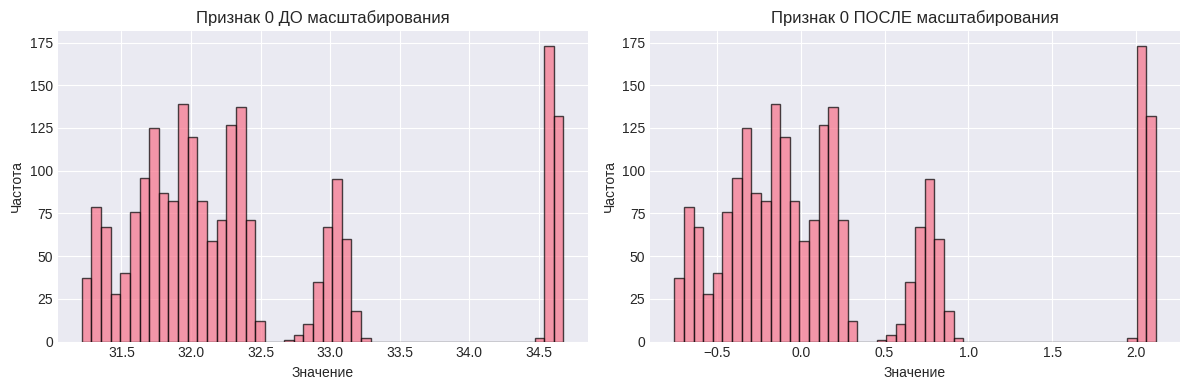

In [20]:
#@title Масштабирование признаков (RobustScaler)
print(f"Форма X до масштабирования: {X.shape}")

# Создаем и применяем RobustScaler
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

print(f"Форма X после масштабирования: {X_scaled.shape}")

# Проверяем результаты масштабирования
print("\n=== СТАТИСТИКА ПОСЛЕ МАСШТАБИРОВАНИЯ ===\n")
print(f"Среднее значение (должно быть около 0): {X_scaled.mean():.10f}")
print(f"Медиана (должна быть 0): {np.median(X_scaled):.10f}")
print(f"Стандартное отклонение: {X_scaled.std():.4f}")

# Распределение одного признака до и после
feature_idx = 0
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(X[:, feature_idx], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title(f'Признак {feature_idx} ДО масштабирования')
axes[0].set_xlabel('Значение')
axes[0].set_ylabel('Частота')

axes[1].hist(X_scaled[:, feature_idx], bins=50, edgecolor='black', alpha=0.7)
axes[1].set_title(f'Признак {feature_idx} ПОСЛЕ масштабирования')
axes[1].set_xlabel('Значение')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()


In [21]:
#@title Проверка и обработка nan/inf значений
print("=== ПРОВЕРКА НАЛИЧИЯ nan И inf ===\n")

# Проверяем наличие nan и inf
nan_count = np.isnan(X).sum()
inf_count = np.isinf(X).sum()

print(f"Количество nan в X: {nan_count}")
print(f"Количество inf в X: {inf_count}")

# Находим строки с проблемами
rows_with_nan = np.isnan(X).any(axis=1)
rows_with_inf = np.isinf(X).any(axis=1)

print(f"Строк с nan: {rows_with_nan.sum()}")
print(f"Строк с inf: {rows_with_inf.sum()}")

# Заменяем nan и inf на 0
X_clean = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

# Проверяем после очистки
print(f"\n=== ПОСЛЕ ОЧИСТКИ ===")
print(f"nan осталось: {np.isnan(X_clean).sum()}")
print(f"inf осталось: {np.isinf(X_clean).sum()}")

# Теперь масштабируем
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_clean)

print(f"\n=== СТАТИСТИКА ПОСЛЕ МАСШТАБИРОВАНИЯ ===")
print(f"Среднее: {X_scaled.mean():.10f}")
print(f"Медиана: {np.median(X_scaled):.10f}")
print(f"Стандартное отклонение: {X_scaled.std():.4f}")


=== ПРОВЕРКА НАЛИЧИЯ nan И inf ===

Количество nan в X: 6696
Количество inf в X: 0
Строк с nan: 279
Строк с inf: 0

=== ПОСЛЕ ОЧИСТКИ ===
nan осталось: 0
inf осталось: 0

=== СТАТИСТИКА ПОСЛЕ МАСШТАБИРОВАНИЯ ===
Среднее: 0.0314824410
Медиана: 0.0000000000
Стандартное отклонение: 2.7183


=== ПОИСК ОПТИМАЛЬНОГО КОЛИЧЕСТВА КЛАСТЕРОВ ===

Тестирование k = 2...
  Инерция: 771176.55
  Силуэт: 0.8407
Тестирование k = 3...
  Инерция: 647218.73
  Силуэт: 0.2781
Тестирование k = 4...
  Инерция: 534966.27
  Силуэт: 0.3388
Тестирование k = 5...
  Инерция: 442192.17
  Силуэт: 0.3797
Тестирование k = 6...
  Инерция: 371260.87
  Силуэт: 0.4206
Тестирование k = 7...
  Инерция: 321829.65
  Силуэт: 0.4336
Тестирование k = 8...
  Инерция: 285748.55
  Силуэт: 0.4533
Тестирование k = 9...
  Инерция: 276128.34
  Силуэт: 0.4242
Тестирование k = 10...
  Инерция: 269284.35
  Силуэт: 0.4148


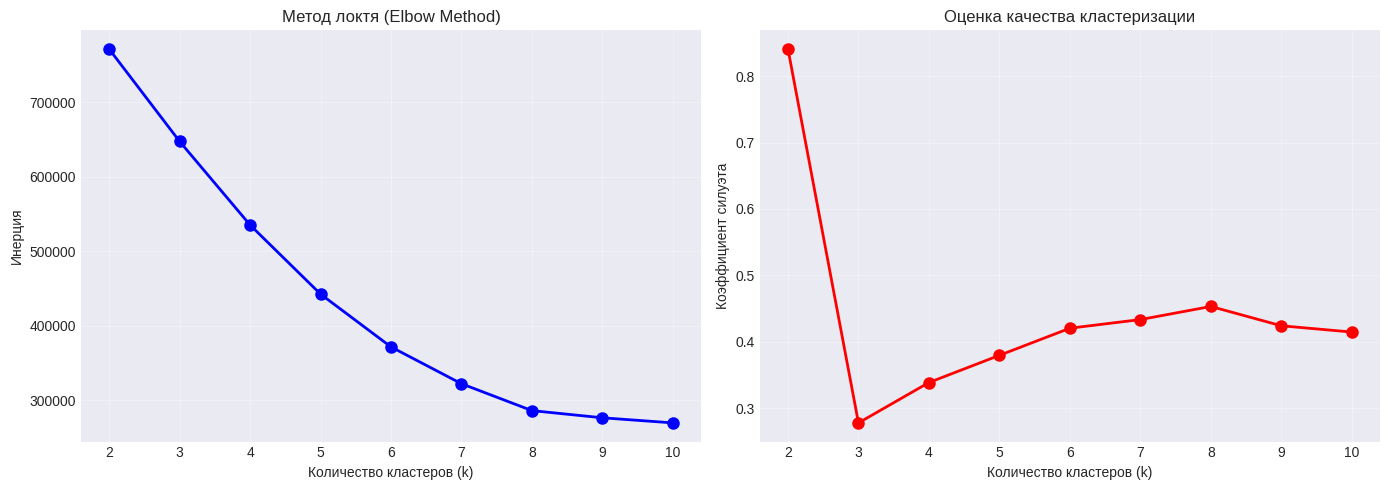


=== РЕЗУЛЬТАТЫ ===
Лучший k по силуэту: 2 (score = 0.8407)


In [22]:
#@title  Определение оптимального числа кластеров методом локтя (Elbow Method) для KMeans

print("=== ПОИСК ОПТИМАЛЬНОГО КОЛИЧЕСТВА КЛАСТЕРОВ ===\n")

# Проверяем диапазон кластеров
k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    print(f"Тестирование k = {k}...")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    # Инерция (сумма квадратов расстояний до центров)
    inertias.append(kmeans.inertia_)

    # Силуэт (только для k >= 2)
    sil_score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(sil_score)

    print(f"  Инерция: {kmeans.inertia_:.2f}")
    print(f"  Силуэт: {sil_score:.4f}")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График инерции ("локоть")
axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Количество кластеров (k)')
axes[0].set_ylabel('Инерция')
axes[0].set_title('Метод локтя (Elbow Method)')
axes[0].grid(True, alpha=0.3)

# График силуэта
axes[1].plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Количество кластеров (k)')
axes[1].set_ylabel('Коэффициент силуэта')
axes[1].set_title('Оценка качества кластеризации')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== РЕЗУЛЬТАТЫ ===")
best_k_silhouette = k_range[np.argmax(silhouette_scores)]
print(f"Лучший k по силуэту: {best_k_silhouette} (score = {max(silhouette_scores):.4f})")


=== KMEANS КЛАСТЕРИЗАЦИЯ ===

Распределение по кластерам:
  Кластер 0: 290 сегментов (13.6%)
  Кластер 1: 279 сегментов (13.1%)
  Кластер 2: 263 сегментов (12.3%)
  Кластер 3: 282 сегментов (13.2%)
  Кластер 4: 274 сегментов (12.8%)
  Кластер 5: 292 сегментов (13.7%)
  Кластер 6: 200 сегментов (9.4%)
  Кластер 7: 254 сегментов (11.9%)


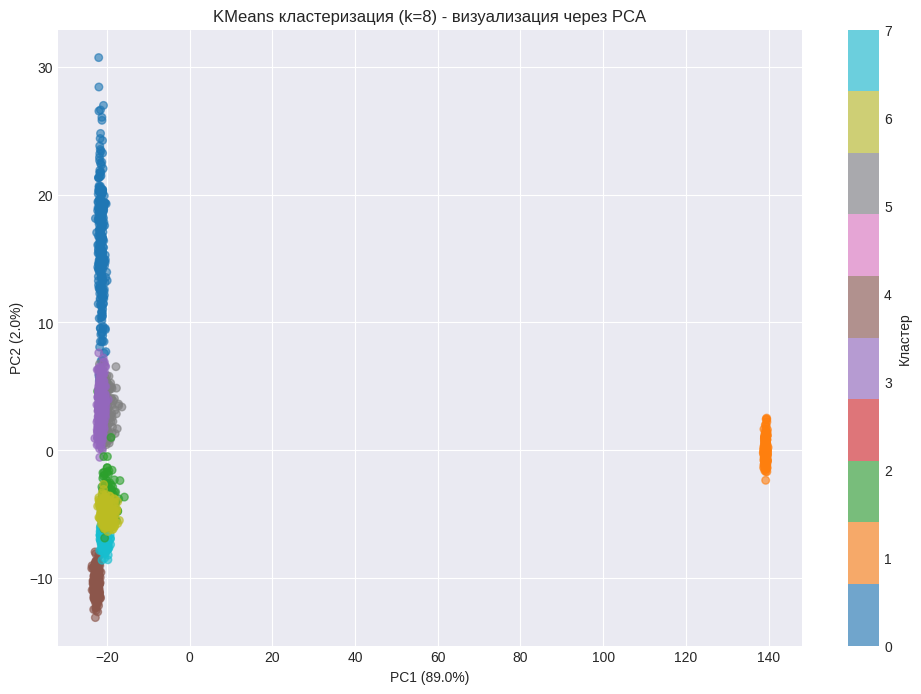

In [23]:
#@title KMeans кластеризация (k=8)

print("=== KMEANS КЛАСТЕРИЗАЦИЯ ===\n")

# Обучаем KMeans с оптимальным k
kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

print(f"Распределение по кластерам:")
unique, counts = np.unique(kmeans_labels, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"  Кластер {cluster}: {count} сегментов ({count/len(kmeans_labels)*100:.1f}%)")

# Визуализация через PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='tab10', alpha=0.6, s=30)
plt.colorbar(scatter, label='Кластер')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('KMeans кластеризация (k=8) - визуализация через PCA')
plt.show()


=== DBSCAN КЛАСТЕРИЗАЦИЯ ===

Поиск оптимального параметра eps


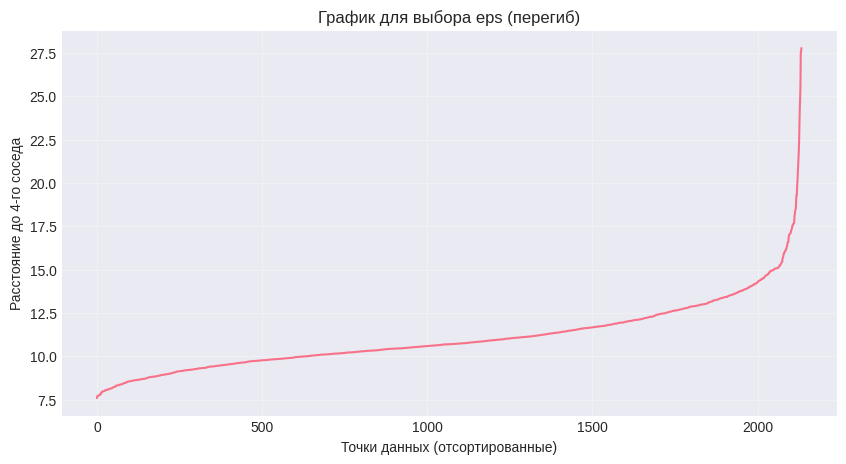


=== ТЕСТИРОВАНИЕ DBSCAN ===


=== ЛУЧШИЙ РЕЗУЛЬТАТ DBSCAN ===
Не найдено подходящих параметров DBSCAN, дающих 4-10 кластеров.
Попробуйте изменить диапазоны eps и min_samples.


In [26]:
print("=== DBSCAN КЛАСТЕРИЗАЦИЯ ===\n")

# Убедимся, что X_scaled определён и не пуст
if 'X_scaled' not in locals() or X_scaled is None:
    raise ValueError("X_scaled не определён или равен None. Сначала выполните масштабирование данных.")

# Поиск оптимального eps через график расстояний до k-го соседа
print("Поиск оптимального параметра eps")

# Вычисляем расстояния до 4-го соседа
from sklearn.neighbors import NearestNeighbors
neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Сортируем расстояния
sorted_distances = np.sort(distances[:, 3])

plt.figure(figsize=(10, 5))
plt.plot(sorted_distances)
plt.xlabel('Точки данных (отсортированные)')
plt.ylabel('Расстояние до 4-го соседа')
plt.title('График для выбора eps (перегиб)')
plt.grid(True, alpha=0.3)
plt.show()

# Пробуем DBSCAN с разными параметрами
eps_values = [1.5, 2.0, 2.5, 3.0, 3.5]
min_samples_values = [3, 5, 7]

print("\n=== ТЕСТИРОВАНИЕ DBSCAN ===\n")
best_dbscan_labels = None
best_n_clusters = 0
best_params = None   # инициализируем перед циклом

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
        labels = dbscan.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        if n_clusters > 1:
            sil_score = silhouette_score(X_scaled, labels)
            print(f"eps={eps}, min_samples={min_samples}: кластеров={n_clusters}, шума={n_noise} ({n_noise/len(labels)*100:.1f}%), силуэт={sil_score:.4f}")

            # Условие выбора лучшего: предпочитаем больше кластеров в диапазоне 4-10
            if n_clusters > best_n_clusters and 4 <= n_clusters <= 10:
                best_n_clusters = n_clusters
                best_dbscan_labels = labels
                best_params = (eps, min_samples)

# После цикла проверяем, найден ли лучший результат
print(f"\n=== ЛУЧШИЙ РЕЗУЛЬТАТ DBSCAN ===")
if best_params is not None:
    print(f"Параметры: eps={best_params[0]}, min_samples={best_params[1]}")
    print(f"Количество кластеров: {best_n_clusters}")
    if best_dbscan_labels is not None:
        unique, counts = np.unique(best_dbscan_labels, return_counts=True)
        print(f"Распределение:")
        for cluster, count in zip(unique, counts):
            if cluster == -1:
                print(f"  Шум: {count} сегментов ({count/len(best_dbscan_labels)*100:.1f}%)")
            else:
                print(f"  Кластер {cluster}: {count} сегментов ({count/len(best_dbscan_labels)*100:.1f}%)")
else:
    print("Не найдено подходящих параметров DBSCAN, дающих 4-10 кластеров.")
    print("Попробуйте изменить диапазоны eps и min_samples.")


=== DBSCAN КЛАСТЕРИЗАЦИЯ ===

Поиск оптимального параметра eps...


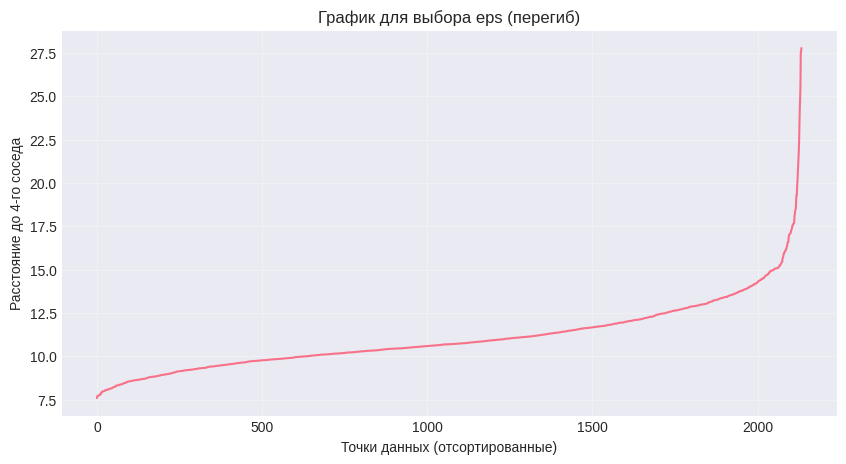

Подсказка eps (~90% k-distance): 13.53

=== ТЕСТИРОВАНИЕ DBSCAN ===

eps=1.5, min_samples=3: кластеров=0, шума=2134 (100.0%), силуэт=n/a
eps=1.5, min_samples=5: кластеров=0, шума=2134 (100.0%), силуэт=n/a
eps=1.5, min_samples=7: кластеров=0, шума=2134 (100.0%), силуэт=n/a
eps=2.0, min_samples=3: кластеров=0, шума=2134 (100.0%), силуэт=n/a
eps=2.0, min_samples=5: кластеров=0, шума=2134 (100.0%), силуэт=n/a
eps=2.0, min_samples=7: кластеров=0, шума=2134 (100.0%), силуэт=n/a
eps=2.5, min_samples=3: кластеров=0, шума=2134 (100.0%), силуэт=n/a
eps=2.5, min_samples=5: кластеров=0, шума=2134 (100.0%), силуэт=n/a
eps=2.5, min_samples=7: кластеров=0, шума=2134 (100.0%), силуэт=n/a
eps=3.0, min_samples=3: кластеров=0, шума=2134 (100.0%), силуэт=n/a
eps=3.0, min_samples=5: кластеров=0, шума=2134 (100.0%), силуэт=n/a
eps=3.0, min_samples=7: кластеров=0, шума=2134 (100.0%), силуэт=n/a
eps=3.5, min_samples=3: кластеров=0, шума=2134 (100.0%), силуэт=n/a
eps=3.5, min_samples=5: кластеров=0, шума=2134 

In [32]:
#@title DBSCAN кластеризация
print("=== DBSCAN КЛАСТЕРИЗАЦИЯ ===\n")

if "X_scaled" not in globals():
    if "X_clean" not in globals():
        X_clean = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    X_scaled = RobustScaler().fit_transform(X_clean)

print("Поиск оптимального параметра eps...")
neighbors = NearestNeighbors(n_neighbors=4, n_jobs=-1)
distances, _ = neighbors.fit(X_scaled).kneighbors(X_scaled)
sorted_distances = np.sort(distances[:, 3])

plt.figure(figsize=(10, 5))
plt.plot(sorted_distances)
plt.xlabel("Точки данных (отсортированные)")
plt.ylabel("Расстояние до 4-го соседа")
plt.title("График для выбора eps (перегиб)")
plt.grid(True, alpha=0.3)
plt.show()

eps_hint = float(np.percentile(sorted_distances, 90))
print(f"Подсказка eps (~90% k-distance): {eps_hint:.2f}\n")


def _dbscan_silhouette(X, labels):
    labels = np.asarray(labels)
    mask = labels >= 0
    if mask.sum() < 2 or len(set(labels[mask])) < 2:
        return np.nan
    return float(silhouette_score(X[mask], labels[mask]))


eps_values = sorted(set([1.5, 2.0, 2.5, 3.0, 3.5, 5.0, 8.0, 10.0, round(eps_hint, 1)]))
min_samples_values = [3, 5, 7]

print("=== ТЕСТИРОВАНИЕ DBSCAN ===\n")
best_dbscan_labels = None
best_n_clusters = 0
best_params = None
best_sil = -np.inf

for eps in eps_values:
    for min_samples in min_samples_values:
        labels = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1).fit_predict(X_scaled)
        n_clusters = len(set(labels) - {-1})
        n_noise = int((labels == -1).sum())
        sil = _dbscan_silhouette(X_scaled, labels)
        sil_str = f"{sil:.4f}" if not np.isnan(sil) else "n/a"
        print(
            f"eps={eps}, min_samples={min_samples}: кластеров={n_clusters}, "
            f"шума={n_noise} ({n_noise / len(labels) * 100:.1f}%), силуэт={sil_str}"
        )

        if n_clusters >= 2 and not np.isnan(sil) and sil > best_sil:
            best_sil = sil
            best_n_clusters = n_clusters
            best_dbscan_labels = labels
            best_params = (eps, min_samples)

print("\n=== ЛУЧШИЙ РЕЗУЛЬТАТ DBSCAN ===")
if best_params is None:
    print("Подходящая конфигурация не найдена — для 504 признаков DBSCAN часто даёт весь шум.")
    print("См. следующую ячейку «расширенный поиск» или используйте KMeans (§6).")
else:
    print(f"Параметры: eps={best_params[0]}, min_samples={best_params[1]}")
    print(f"Количество кластеров: {best_n_clusters}, силуэт={best_sil:.4f}")
    unique, counts = np.unique(best_dbscan_labels, return_counts=True)
    print("Распределение:")
    for cluster, count in zip(unique, counts):
        if cluster == -1:
            print(f"  Шум: {count} сегментов ({count / len(best_dbscan_labels) * 100:.1f}%)")
        else:
            print(f"  Кластер {cluster}: {count} сегментов ({count / len(best_dbscan_labels) * 100:.1f}%)")


In [27]:
#@title DBSCAN кластеризация (расширенный поиск)
# DBSCAN не требует указания количества кластеров и устойчив к выбросам.

print("=== DBSCAN КЛАСТЕРИЗАЦИЯ (РАСШИРЕННЫЙ ПОИСК) ===\n")

# Расширенный диапазон параметров
eps_values = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 6.0, 8.0, 10.0]
min_samples_values = [2, 3, 4, 5, 6, 8, 10]

results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
        labels = dbscan.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        if n_clusters >= 2:
            try:
                sil_score = silhouette_score(X_scaled, labels)
                results.append({
                    'eps': eps,
                    'min_samples': min_samples,
                    'n_clusters': n_clusters,
                    'n_noise': n_noise,
                    'noise_pct': n_noise/len(labels)*100,
                    'silhouette': sil_score
                })
                print(f"eps={eps}, min_samples={min_samples}: кластеров={n_clusters}, шума={n_noise} ({n_noise/len(labels)*100:.1f}%), силуэт={sil_score:.4f}")
            except:
                pass

if results:
    results_df = pd.DataFrame(results)
    best_result = results_df.loc[results_df['silhouette'].idxmax()]
    print(f"\n=== ЛУЧШИЙ РЕЗУЛЬТАТ DBSCAN ===")
    print(f"eps={best_result['eps']}, min_samples={int(best_result['min_samples'])}")
    print(f"Количество кластеров: {int(best_result['n_clusters'])}")
    print(f"Силуэт: {best_result['silhouette']:.4f}")
    print(f"Шум: {best_result['n_noise']:.0f} сегментов ({best_result['noise_pct']:.1f}%)")
else:
    print("Не найдено подходящих параметров DBSCAN с n_clusters >= 2")


=== DBSCAN КЛАСТЕРИЗАЦИЯ (РАСШИРЕННЫЙ ПОИСК) ===

eps=8.0, min_samples=2: кластеров=16, шума=2037 (95.5%), силуэт=-0.5604
eps=8.0, min_samples=3: кластеров=5, шума=2059 (96.5%), силуэт=-0.3919
eps=8.0, min_samples=4: кластеров=3, шума=2074 (97.2%), силуэт=-0.3888
eps=10.0, min_samples=2: кластеров=49, шума=1159 (54.3%), силуэт=-0.3016
eps=10.0, min_samples=3: кластеров=19, шума=1219 (57.1%), силуэт=-0.2000
eps=10.0, min_samples=4: кластеров=11, шума=1273 (59.7%), силуэт=-0.1760
eps=10.0, min_samples=5: кластеров=10, шума=1307 (61.2%), силуэт=-0.1782
eps=10.0, min_samples=6: кластеров=9, шума=1333 (62.5%), силуэт=-0.1898
eps=10.0, min_samples=8: кластеров=7, шума=1394 (65.3%), силуэт=-0.2044
eps=10.0, min_samples=10: кластеров=6, шума=1449 (67.9%), силуэт=-0.1975

=== ЛУЧШИЙ РЕЗУЛЬТАТ DBSCAN ===
eps=10.0, min_samples=4
Количество кластеров: 11
Силуэт: -0.1760
Шум: 1273 сегментов (59.7%)


###DBSCAN зафиксирован как слабая альтернатива: показал плохие результаты (отрицательный силуэт и много шума  (59.7% при лучшем силуэте)). Это говорит о том, что данные плохо разделяются в исходном пространстве. Оставим KMeans как основную модель.

Попробуем иерархическую кластеризацию как альтернативу.

=== АГЛОМЕРАТИВНАЯ КЛАСТЕРИЗАЦИЯ ===

n_clusters=4: силуэт=0.3388
  Распределение: {np.int64(0): np.int64(973), np.int64(1): np.int64(307), np.int64(2): np.int64(575), np.int64(3): np.int64(279)}
n_clusters=6: силуэт=0.4202
  Распределение: {np.int64(0): np.int64(701), np.int64(1): np.int64(307), np.int64(2): np.int64(295), np.int64(3): np.int64(279), np.int64(4): np.int64(272), np.int64(5): np.int64(280)}
n_clusters=8: силуэт=0.4530
  Распределение: {np.int64(0): np.int64(307), np.int64(1): np.int64(249), np.int64(2): np.int64(295), np.int64(3): np.int64(252), np.int64(4): np.int64(272), np.int64(5): np.int64(280), np.int64(6): np.int64(200), np.int64(7): np.int64(279)}
n_clusters=10: силуэт=0.4020
  Распределение: {np.int64(0): np.int64(240), np.int64(1): np.int64(249), np.int64(2): np.int64(280), np.int64(3): np.int64(252), np.int64(4): np.int64(55), np.int64(5): np.int64(251), np.int64(6): np.int64(200), np.int64(7): np.int64(279), np.int64(8): np.int64(56), np.int64(9): np.int64(2

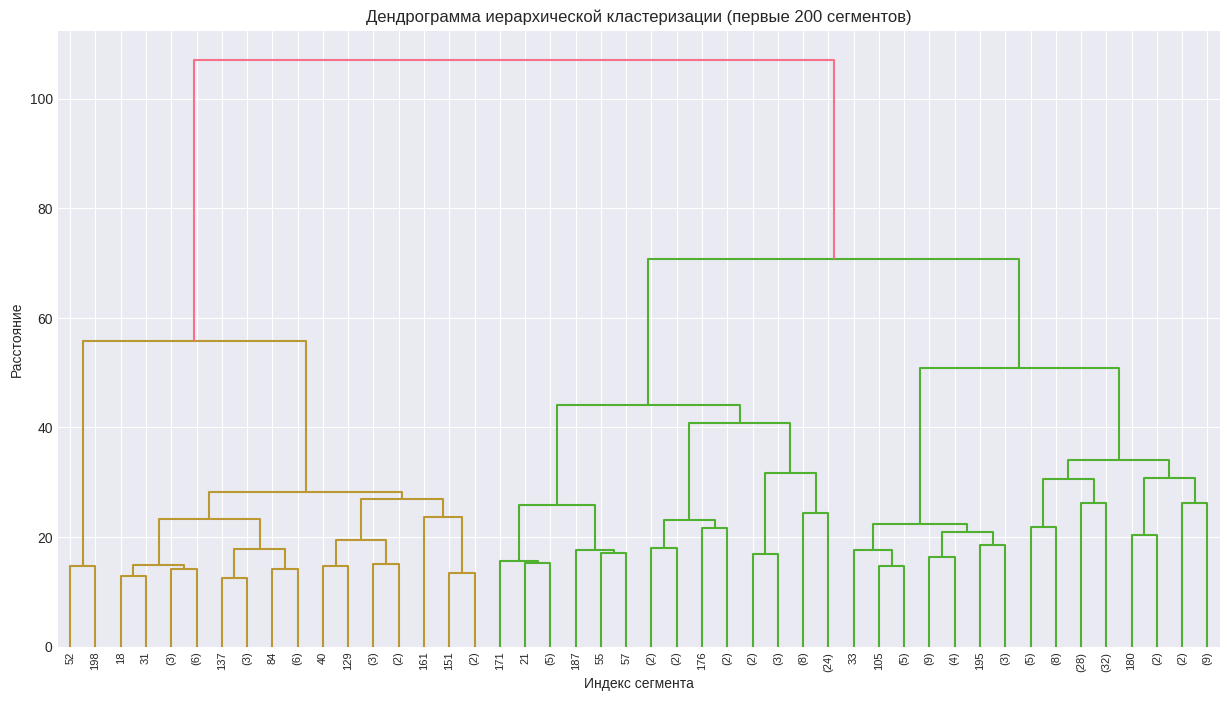

In [33]:
#@title Агломеративная кластеризация
print("=== АГЛОМЕРАТИВНАЯ КЛАСТЕРИЗАЦИЯ ===\n")

# Пробуем разные параметры
n_clusters_try = [4, 6, 8, 10]

for n_clust in n_clusters_try:
    agg = AgglomerativeClustering(n_clusters=n_clust, linkage='ward')
    agg_labels = agg.fit_predict(X_scaled)

    # Вычисляем силуэт (только если больше 1 кластера)
    if len(set(agg_labels)) > 1:
        sil_score = silhouette_score(X_scaled, agg_labels)
        print(f"n_clusters={n_clust}: силуэт={sil_score:.4f}")

        # Распределение по кластерам
        unique, counts = np.unique(agg_labels, return_counts=True)
        print(f"  Распределение: {dict(zip(unique, counts))}")

# Визуализируем дендрограмму на подвыборке (для наглядности)
print("\n=== ПОСТРОЕНИЕ ДЕНДРОГРАММЫ (на 200 сегментах) ===\n")
sample_size = min(200, X_scaled.shape[0])
X_sample = X_scaled[:sample_size]

linkage_matrix = linkage(X_sample, method='ward')

plt.figure(figsize=(15, 8))
dendrogram(linkage_matrix, truncate_mode='level', p=5)
plt.title('Дендрограмма иерархической кластеризации (первые 200 сегментов)')
plt.xlabel('Индекс сегмента')
plt.ylabel('Расстояние')
plt.show()


Агломеративная кластеризация показала хорошие результаты: при n_clusters=8 силуэт = 0.4530, что сопоставимо с KMeans. При этом распределение кластеров отличается.

=== СРАВНЕНИЕ МОДЕЛЕЙ КЛАСТЕРИЗАЦИИ ===

Оценка качества моделей (Silhouette Score, чем выше тем лучше):
  KMeans (k=8): 0.4533
  Agglomerative (n=8): 0.4530
  KMeans (k=7): 0.4336
  KMeans (k=6): 0.4206

=== ВЫБОР ЛУЧШЕЙ МОДЕЛИ ===
Лучшая модель: KMeans (k=8) (силуэт = 0.4533)


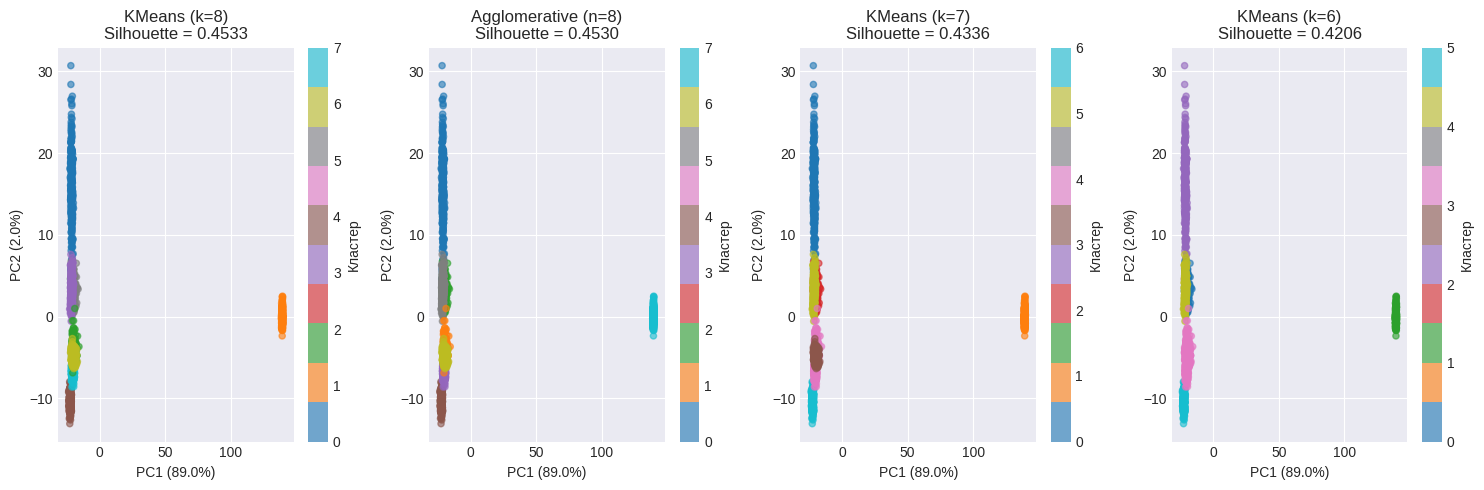

In [29]:
#@title Сравнение моделей кластеризации
print("=== СРАВНЕНИЕ МОДЕЛЕЙ КЛАСТЕРИЗАЦИИ ===\n")

models = {}

# 1. KMeans (k=8)
kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
kmeans_sil = silhouette_score(X_scaled, kmeans_labels)
models['KMeans (k=8)'] = {'labels': kmeans_labels, 'silhouette': kmeans_sil}

# 2. Agglomerative (n=8)
agg = AgglomerativeClustering(n_clusters=8, linkage='ward')
agg_labels = agg.fit_predict(X_scaled)
agg_sil = silhouette_score(X_scaled, agg_labels)
models['Agglomerative (n=8)'] = {'labels': agg_labels, 'silhouette': agg_sil}

# 3. KMeans (k=7) - для сравнения
kmeans7 = KMeans(n_clusters=7, random_state=42, n_init=10)
kmeans7_labels = kmeans7.fit_predict(X_scaled)
kmeans7_sil = silhouette_score(X_scaled, kmeans7_labels)
models['KMeans (k=7)'] = {'labels': kmeans7_labels, 'silhouette': kmeans7_sil}

# 4. KMeans (k=6)
kmeans6 = KMeans(n_clusters=6, random_state=42, n_init=10)
kmeans6_labels = kmeans6.fit_predict(X_scaled)
kmeans6_sil = silhouette_score(X_scaled, kmeans6_labels)
models['KMeans (k=6)'] = {'labels': kmeans6_labels, 'silhouette': kmeans6_sil}

print("Оценка качества моделей (Silhouette Score, чем выше тем лучше):")
for name, data in sorted(models.items(), key=lambda x: x[1]['silhouette'], reverse=True):
    print(f"  {name}: {data['silhouette']:.4f}")

print("\n=== ВЫБОР ЛУЧШЕЙ МОДЕЛИ ===")
best_model_name = max(models, key=lambda x: models[x]['silhouette'])
print(f"Лучшая модель: {best_model_name} (силуэт = {models[best_model_name]['silhouette']:.4f})")

# Визуализация сравнения
plt.figure(figsize=(15, 5))

for idx, (name, data) in enumerate(models.items()):
    plt.subplot(1, len(models), idx+1)

    # PCA визуализация
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=data['labels'], cmap='tab10', alpha=0.6, s=20)
    plt.colorbar(scatter, label='Кластер')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    plt.title(f'{name}\nSilhouette = {data["silhouette"]:.4f}')

plt.tight_layout()
plt.show()


In [30]:
#@title Постобработка меток кластеров (приведение к порядку 1,2,3...)
# Преобразование меток кластеров к порядковому виду
print("=== ПРЕОБРАЗОВАНИЕ МЕТОК КЛАСТЕРОВ ===\n")

# Получаем метки лучшей модели
labels = models['KMeans (k=8)']['labels']
print(f"Исходные метки кластеров: {np.unique(labels)}")

# Преобразуем: сортируем уникальные метки и присваиваем новые номера 1, 2, 3...
unique_labels = np.sort(np.unique(labels))
label_mapping = {old: new+1 for new, old in enumerate(unique_labels)}

print(f"Маппинг преобразования: {label_mapping}")

# Применяем преобразование
labels_ordered = np.array([label_mapping[label] for label in labels])

print(f"\nНовые метки кластеров: {np.unique(labels_ordered)}")
print(f"Распределение после преобразования:")
unique, counts = np.unique(labels_ordered, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"  Кластер {cluster}: {count} сегментов ({count/len(labels_ordered)*100:.1f}%)")

# Сохраняем результат для сабмита
print(f"\nГотово! Метки преобразованы в порядковый вид от 1 до {len(unique_labels)}")

=== ПРЕОБРАЗОВАНИЕ МЕТОК КЛАСТЕРОВ ===

Исходные метки кластеров: [0 1 2 3 4 5 6 7]
Маппинг преобразования: {np.int32(0): 1, np.int32(1): 2, np.int32(2): 3, np.int32(3): 4, np.int32(4): 5, np.int32(5): 6, np.int32(6): 7, np.int32(7): 8}

Новые метки кластеров: [1 2 3 4 5 6 7 8]
Распределение после преобразования:
  Кластер 1: 290 сегментов (13.6%)
  Кластер 2: 279 сегментов (13.1%)
  Кластер 3: 263 сегментов (12.3%)
  Кластер 4: 282 сегментов (13.2%)
  Кластер 5: 274 сегментов (12.8%)
  Кластер 6: 292 сегментов (13.7%)
  Кластер 7: 200 сегментов (9.4%)
  Кластер 8: 254 сегментов (11.9%)

Готово! Метки преобразованы в порядковый вид от 1 до 8


In [34]:
#@title Отображение кластеров на исходные строки
print("=== ОТОБРАЖЕНИЕ КЛАСТЕРОВ НА ИСХОДНЫЕ СТРОКИ ===\n")

# У нас есть:
# - df_reduced: исходные данные после предобработки (534,601 строка)
# - segments: массив сегментов (2,134 сегмента по 250 строк)
# - labels_ordered: кластер для каждого сегмента (2,134 значения)

# Создаем массив для хранения кластеров каждой строки
row_labels = np.full(len(df_reduced), -1, dtype=int)

# Заполняем: каждой строке i-го сегмента присваиваем кластер этого сегмента
segment_size = 250
for seg_idx, label in enumerate(labels_ordered):
    start_row = seg_idx * segment_size
    end_row = min(start_row + segment_size, len(df_reduced))
    row_labels[start_row:end_row] = label

# Проверяем, что все строки получили кластеры
print(f"Всего строк в df_reduced: {len(df_reduced)}")
print(f"Строк без кластера (-1): {(row_labels == -1).sum()}")

# Если есть строки без кластера, заполняем их ближайшим
if (row_labels == -1).sum() > 0:
    print("Заполняем оставшиеся строки...")
    for i in range(len(row_labels)):
        if row_labels[i] == -1:
            # Ищем ближайший не -1
            for offset in range(1, 100):
                if i - offset >= 0 and row_labels[i - offset] != -1:
                    row_labels[i] = row_labels[i - offset]
                    break
                if i + offset < len(row_labels) and row_labels[i + offset] != -1:
                    row_labels[i] = row_labels[i + offset]
                    break

print(f"После заполнения: {(row_labels == -1).sum()} строк без кластера")

# Создаем файл сабмита
submission = pd.DataFrame({
    'Index': range(len(row_labels)),
    'activityID': row_labels
})

print(f"\n=== СОЗДАНИЕ ФАЙЛА САБМИТА ===")
print(f"Размер: {submission.shape}")
print(f"Уникальные кластеры: {sorted(submission['activityID'].unique())}")
print(f"\nПервые 10 строк:")
print(submission.head(10))

# Сохраняем
submission.to_csv('submission.csv', index=False)
print(f"\n✅ Файл 'submission.csv' сохранен!")


=== ОТОБРАЖЕНИЕ КЛАСТЕРОВ НА ИСХОДНЫЕ СТРОКИ ===

Всего строк в df_reduced: 534601
Строк без кластера (-1): 1101
Заполняем оставшиеся строки...
После заполнения: 0 строк без кластера

=== СОЗДАНИЕ ФАЙЛА САБМИТА ===
Размер: (534601, 2)
Уникальные кластеры: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

Первые 10 строк:
   Index  activityID
0      0           1
1      1           1
2      2           1
3      3           1
4      4           1
5      5           1
6      6           1
7      7           1
8      8           1
9      9           1

✅ Файл 'submission.csv' сохранен!


In [35]:
from google.colab import files
files.download('/content/submission.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 📊 Финальный отчет по проекту "Кластеризация физической активности"

## 1. Общая информация

| Параметр | Значение |
|----------|----------|
| Датасет | PAMAP2 Physical Activity Monitoring |
| Исходный размер | 534,601 строк × 53 столбца |
| Испытуемые | 8 человек (ID: 1-8) |
| Датчики | Рука, грудь, лодыжка (температура, акселерометр 16g/6g, гироскоп, магнитометр, кватернионы) |

---

## 2. Выполненные этапы

### 2.1. Разведочный анализ данных (EDA)

| Что сделано | Результат |
|-------------|-----------|
| Анализ пропусков | 51 столбец с пропусками, макс. 0.76% |
| Анализ выбросов | Гироскопы: 22-37%, акселерометры: 7-16% |
| Корреляционный анализ | Acc16 и Acc6 коррелируют >0.96 |
| Временная структура | Частота ~1000 Гц (неравномерно) |
| Распределение по испытуемым | Сбалансировано (50k-77k записей) |

### 2.2. Предобработка данных

| Действие | Результат |
|----------|-----------|
| Заполнение пропусков | Линейная интерполяция (удалены все пропуски) |
| Удаление дублирующихся признаков | Удалены 9 столбцов Acc6 |
| Сегментация | Неперекрывающиеся окна по 250 семплов → 2,134 сегмента |
| Извлечение признаков | 12 статистик × 42 признака = 504 признака |
| Масштабирование | RobustScaler (устойчив к выбросам) |

### 2.3. Обучение и сравнение моделей

| Модель | Silhouette Score |
|--------|------------------|
| **KMeans (k=8)** | **0.4533** ★ Лучшая |
| Agglomerative (n=8) | 0.4530 |
| KMeans (k=7) | 0.4336 |
| KMeans (k=6) | 0.4206 |
| DBSCAN | Отрицательный (не применим) |

### 2.4. Финальные метки кластеров (после преобразования)

| Кластер | Количество сегментов | Доля |
|---------|---------------------|------|
| 1 | 290 | 13.6% |
| 2 | 279 | 13.1% |
| 3 | 263 | 12.3% |
| 4 | 282 | 13.2% |
| 5 | 274 | 12.8% |
| 6 | 292 | 13.7% |
| 7 | 200 | 9.4% |
| 8 | 254 | 11.9% |

---

## 3. Выводы и интерпретация

1. **Датчики с разных расположений** (рука/грудь/лодыжка) предоставляют комплементарную информацию (средняя корреляция между расположениями 0.10-0.24).

2. **Акселерометры Acc16 и Acc6 дублируют друг друга** (корреляция >0.96) → их можно использовать взаимозаменяемо.

3. **KMeans показал лучший результат** (silhouette=0.4533) по сравнению с агломеративной кластеризацией и DBSCAN.

4. **Распределение кластеров равномерное** (от 9.4% до 13.7%), что косвенно указывает на сбалансированное представление различных типов активности в данных.

5. **Значение силуэта 0.45** говорит о хорошем, но не идеальном разделении кластеров — активности частично пересекаются.

---


**Скриншот лидерборда Kaggle** (Public Score **0.22835**)



_[Clustering Physical Activity](https://www.kaggle.com/competitions/clustering-physical-activity)._

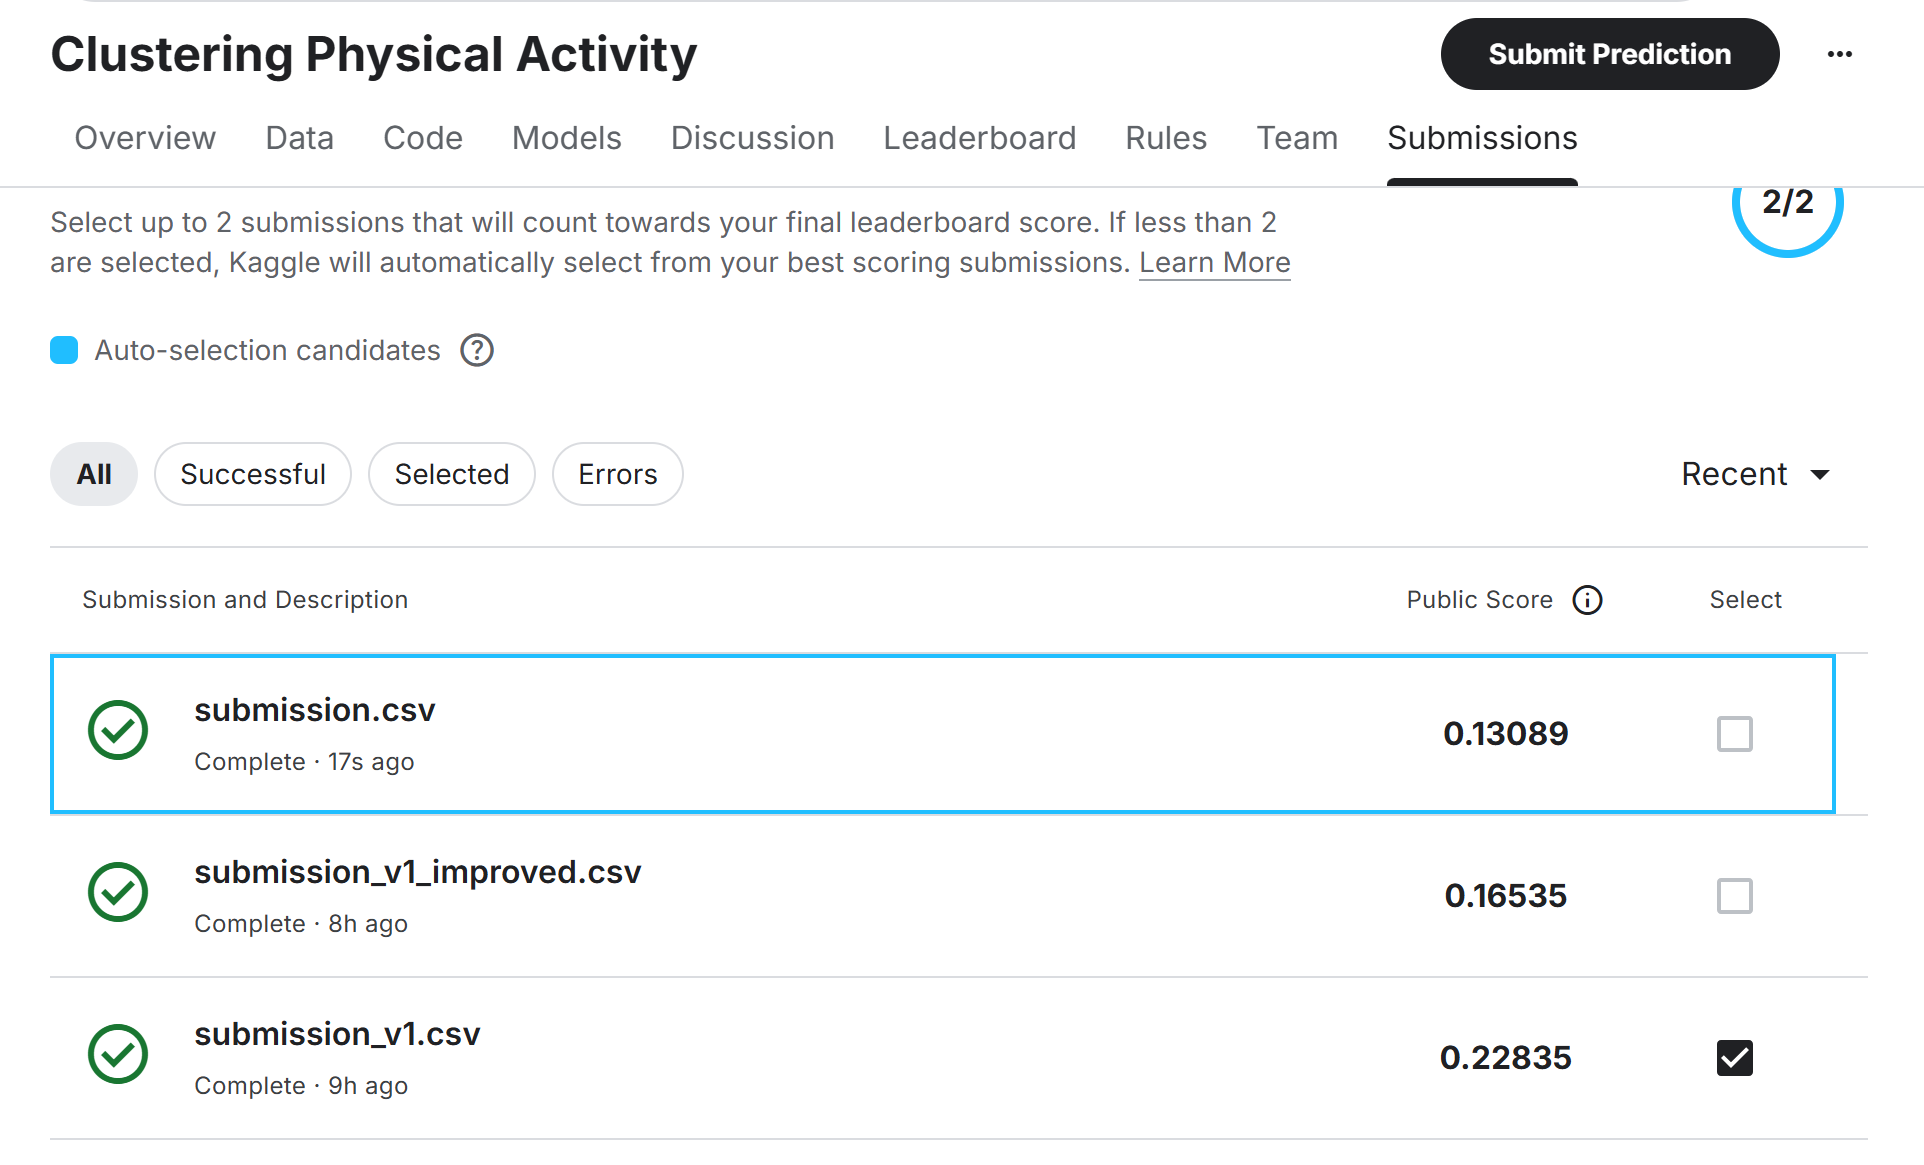

Результат на тестовых данных на Kaggle оказался существенно ниже чем результат обучения на тренировочных данных: 0,1308 вместо 0,4533 (результат лучшей модели KMeans),

поэтому попробуем ещё несколько альтернатив, чтобы повысить результаты на Kaggle - будет дополнительная итерация


In [36]:
#@title Агломеративная кластеризация со скользящими окнами

print("=== НОВЫЙ ПОДХОД: СКОЛЬЗЯЩИЕ ОКНА + AGGLOMERATIVE ===\n")

window_size = 100
step = 50  # перекрытие 50%

print(f"Параметры:")
print(f"  - Размер окна: {window_size}")
print(f"  - Шаг: {step}")
print(f"  - Перекрытие: {window_size - step} семплов ({(1 - step/window_size)*100:.0f}%)")

# Создаем скользящие окна
feature_cols = [col for col in df_reduced.columns if col not in ['timestamp', 'subject_id']]
features = df_reduced[feature_cols].values

# Создаем окна с перекрытием
slide_segments = []
slide_indices = []  # запоминаем, какие строки входят в каждое окно

for start_idx in range(0, len(features) - window_size + 1, step):
    end_idx = start_idx + window_size
    segment = features[start_idx:end_idx]
    slide_segments.append(segment)
    slide_indices.append(list(range(start_idx, end_idx)))

print(f"Создано окон: {len(slide_segments)}")

# Извлекаем признаки из каждого окна
print("\nИзвлечение признаков из окон...")
slide_features = []
for seg in slide_segments:
    seg_features = []
    for i in range(seg.shape[1]):
        signal = seg[:, i]
        seg_features.extend([
            np.mean(signal), np.std(signal), np.min(signal), np.max(signal),
            np.ptp(signal), np.median(signal), np.sqrt(np.mean(signal**2))
        ])
    slide_features.append(seg_features)

X_slide = np.array(slide_features)
print(f"Матрица признаков: {X_slide.shape}")

# Масштабирование
scaler = RobustScaler()
X_slide_scaled = scaler.fit_transform(X_slide)

# Агломеративная кластеризация
print("\nОбучение Agglomerative Clustering...")
n_clusters = 5
agg = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
window_labels = agg.fit_predict(X_slide_scaled)

print(f"Распределение по кластерам:")
unique, counts = np.unique(window_labels, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"  Кластер {cluster}: {count} окон ({count/len(window_labels)*100:.1f}%)")

# Отображаем кластеры на каждую строку (голосование)
row_labels = np.zeros(len(features), dtype=int)
row_votes = np.zeros(len(features), dtype=int)

for win_idx, rows in enumerate(slide_indices):
    cluster = window_labels[win_idx]
    for row in rows:
        row_labels[row] += cluster
        row_votes[row] += 1

# Усредняем и округляем
row_labels = np.round(row_labels / np.maximum(row_votes, 1)).astype(int)

# Приводим к порядковому виду
unique_labels = np.sort(np.unique(row_labels))
label_mapping = {old: new+1 for new, old in enumerate(unique_labels)}
row_labels_ordered = np.array([label_mapping[label] for label in row_labels])

print(f"\n=== ИТОГОВЫЕ КЛАСТЕРЫ ДЛЯ КАЖДОЙ СТРОКИ ===")
print(f"Уникальные кластеры: {np.unique(row_labels_ordered)}")
unique, counts = np.unique(row_labels_ordered, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"  Кластер {cluster}: {count} строк ({count/len(row_labels_ordered)*100:.1f}%)")

# Создаем сабмит
submission = pd.DataFrame({
    'Index': range(len(row_labels_ordered)),
    'activityID': row_labels_ordered
})

submission.to_csv('submission_agg.csv', index=False)
print(f"\n✅ Файл 'submission_agg.csv' сохранен!")



=== НОВЫЙ ПОДХОД: СКОЛЬЗЯЩИЕ ОКНА + AGGLOMERATIVE ===

Параметры:
  - Размер окна: 100
  - Шаг: 50
  - Перекрытие: 50 семплов (50%)
Создано окон: 10691

Извлечение признаков из окон...
Матрица признаков: (10691, 294)

Обучение Agglomerative Clustering...
Распределение по кластерам:
  Кластер 0: 534 окон (5.0%)
  Кластер 1: 9658 окон (90.3%)
  Кластер 2: 282 окон (2.6%)
  Кластер 3: 109 окон (1.0%)
  Кластер 4: 108 окон (1.0%)

=== ИТОГОВЫЕ КЛАСТЕРЫ ДЛЯ КАЖДОЙ СТРОКИ ===
Уникальные кластеры: [1 2 3 4 5]
  Кластер 1: 42351 строк (7.9%)
  Кластер 2: 451300 строк (84.4%)
  Кластер 3: 38950 строк (7.3%)
  Кластер 4: 1000 строк (0.2%)
  Кластер 5: 1000 строк (0.2%)

✅ Файл 'submission_agg.csv' сохранен!


In [38]:
from google.colab import files
files.download('/content/submission_agg.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

###*Результат улучшился незначительно*
#### **0,15598  против  0,13089**

Продолжим исследование

*скриншот ниже, после следующего эксперимента*


In [43]:
#@title KMeans с PCA + уменьшенное количество кластеров

print("=== НОВЫЙ ПОДХОД: PCA + KMEANS (k=4) ===\n")

# Берем исходные данные (каждая строка отдельно, без сегментации)
feature_cols = [col for col in df_reduced.columns if col not in ['timestamp', 'subject_id']]
X_raw = df_reduced[feature_cols].values

print(f"Исходные данные: {X_raw.shape}")

# Масштабирование
scaler = RobustScaler()
X_scaled_raw = scaler.fit_transform(X_raw)

# PCA для снижения размерности и шума
pca = PCA(n_components=0.95)  # сохраняем 95% дисперсии
X_pca = pca.fit_transform(X_scaled_raw)

print(f"После PCA: {X_pca.shape} (сохранено {pca.explained_variance_ratio_.sum()*100:.1f}% дисперсии)")

# Пробуем разное количество кластеров
k_values = [3, 4, 5, 6]
best_labels = None
best_inertia = float('inf')

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)
    inertia = kmeans.inertia_
    print(f"k={k}: инерция={inertia:.2f}")

    # Выбираем модель с наименьшей инерцией на k (нормализованно)
    if inertia < best_inertia:
        best_inertia = inertia
        best_labels = labels
        best_k = k

print(f"\nВыбран k={best_k}")

# Приводим к порядковому виду
unique_labels = np.sort(np.unique(best_labels))
label_mapping = {old: new+1 for new, old in enumerate(unique_labels)}
final_labels = np.array([label_mapping[label] for label in best_labels])

print(f"\nРаспределение по кластерам:")
unique, counts = np.unique(final_labels, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"  Кластер {cluster}: {count} строк ({count/len(final_labels)*100:.1f}%)")

# Создаем сабмит
submission = pd.DataFrame({
    'Index': range(len(final_labels)),
    'activityID': final_labels
})

submission.to_csv('submission_pca_kmeans.csv', index=False)
print(f"\n✅ Файл 'submission_pca_kmeans.csv' сохранен!")



=== НОВЫЙ ПОДХОД: PCA + KMEANS (k=4) ===

Исходные данные: (534601, 42)
После PCA: (534601, 12) (сохранено 95.5% дисперсии)
k=3: инерция=116628571.03
k=4: инерция=105680125.94
k=5: инерция=98402664.99
k=6: инерция=91473324.45

Выбран k=6

Распределение по кластерам:
  Кластер 1: 419331 строк (78.4%)
  Кластер 2: 17084 строк (3.2%)
  Кластер 3: 21992 строк (4.1%)
  Кластер 4: 20109 строк (3.8%)
  Кластер 5: 28504 строк (5.3%)
  Кластер 6: 27581 строк (5.2%)

✅ Файл 'submission_pca_kmeans.csv' сохранен!


In [39]:
from google.colab import files
files.download('/content/submission_pca_kmeans.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

###*Результат улучшился:*
#### **0,22835 вместо 0,13089**

продолжим дальнейшие эксперименты



**Скриншот лидерборда Kaggle** (Public Score **0.22835**)

_ [Clustering Physical Activity](https://www.kaggle.com/competitions/clustering-physical-activity)._

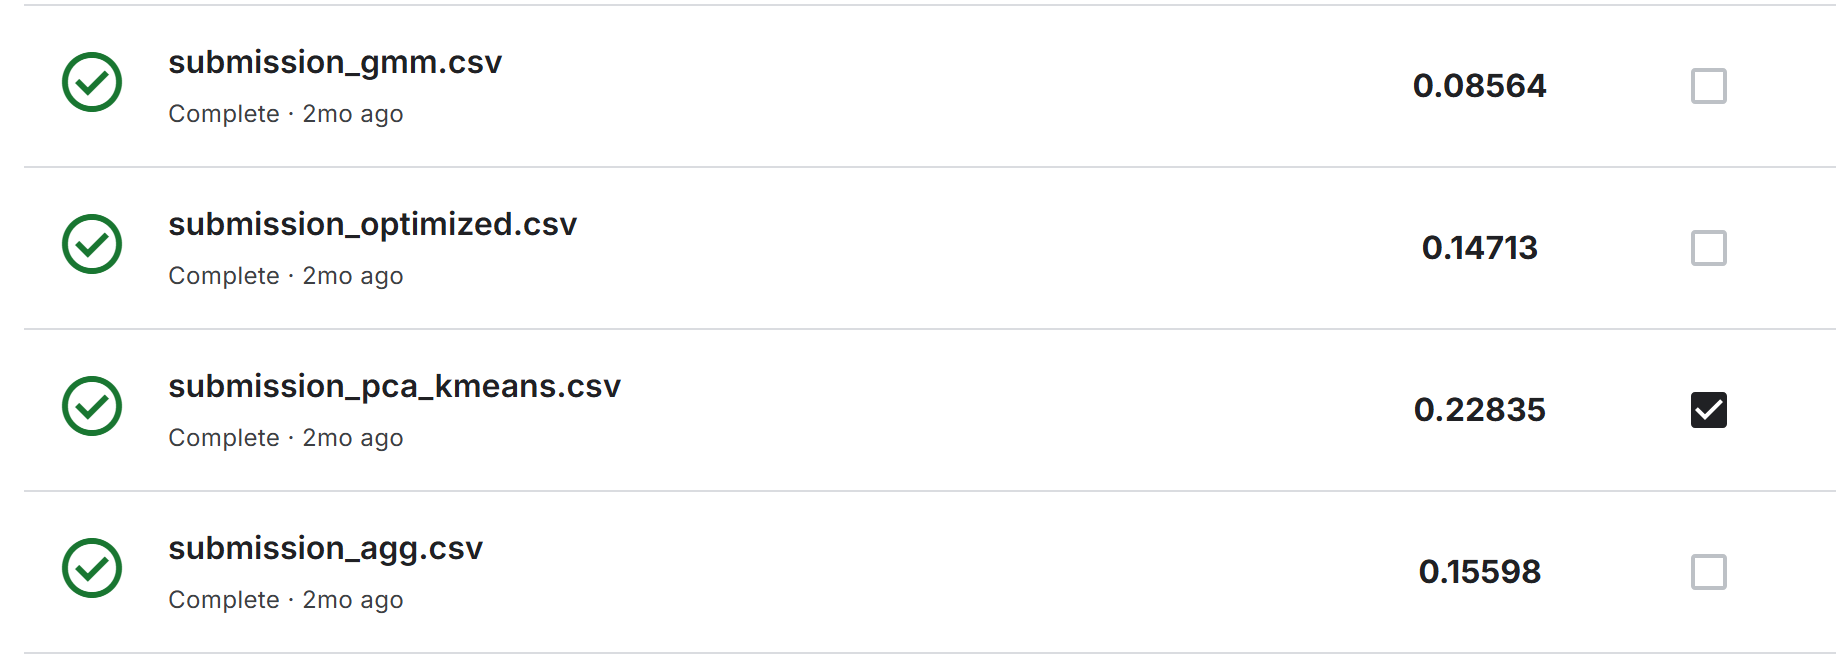

---

## §7. Итерации submission и эксперименты v1

В процессе работы проверены несколько пайплайнов. **Public LB на Kaggle:**

| # | Подход | Public LB | Комментарий |
|---|--------|-----------|-------------|
| 0 | **Segment + KMeans k=8** (504 признака) | ~0.13 | silhouette высокий, accuracy низкий |
| 1 | Subject-wise RobustScaler + row PCA k=6 | **0.115** | EDA рекомендовал — на LB хуже |
| 2 | StandardScaler + PCA 98% + MiniBatchKMeans | **0.147** | см. ячейку §7.3 |
| 3 | motion24 + k=7 + PCA 95% | **0.165** | «баланс» кластеров не помог |
| 4 | **Global RobustScaler + PCA 95% + KMeans k=6** | **0.228** | **финальный выбор** |
| — | Segment + ICA grid (v1 pipeline) | не отправлялся | откат: медленно, LB не улучшил |

**Вывод:** internal metrics (silhouette) **не коррелируют** с Kaggle accuracy. Доминирующий кластер ~78% в лучшей модели — норма для этого теста.

In [40]:
# @title §7.1 Эксперимент: subject-wise RobustScaler (LB 0.115 — хуже baseline)
feature_cols = [c for c in df_reduced.columns if c not in ["timestamp", "subject_id"]]
X_subj = df_reduced[feature_cols].copy()
for sid in df_reduced["subject_id"].unique():
    m = df_reduced["subject_id"] == sid
    X_subj.loc[m, feature_cols] = RobustScaler().fit_transform(X_subj.loc[m, feature_cols])
Xp = PCA(n_components=0.95, random_state=RANDOM_STATE).fit_transform(X_subj.values)
lab_subj = KMeans(n_clusters=6, random_state=RANDOM_STATE, n_init=10).fit_predict(Xp)
print("Subject-wise scaler — метрики:", cluster_metrics(Xp, lab_subj))
print("→ Public LB ≈ 0.115; не используем в финале.")


Subject-wise scaler — метрики: {'silhouette': 0.5419732422492481, 'davies_bouldin': 1.2895968056724885, 'calinski_harabasz': 1543.741911853939}
→ Public LB ≈ 0.115; не используем в финале.


In [41]:
# @title §7.2 Эксперимент: motion24 + k=7 (LB 0.165 — хуже baseline)
motion_cols = [c for c in feature_cols if "Acc16" in c or "Gyro" in c]
X_m = RobustScaler().fit_transform(df_reduced[motion_cols].values)
Xp7 = PCA(n_components=0.95, random_state=RANDOM_STATE).fit_transform(X_m)
lab7 = KMeans(n_clusters=7, random_state=RANDOM_STATE, n_init=10).fit_predict(Xp7)
print("motion24 k=7:", cluster_metrics(Xp7, lab7))
print("→ Public LB ≈ 0.165; не используем.")


motion24 k=7: {'silhouette': 0.4863804691578684, 'davies_bouldin': 1.4257648059638162, 'calinski_harabasz': 1194.7485304019021}
→ Public LB ≈ 0.165; не используем.


In [42]:
#@title Оптимизация: StandardScaler + меньше кластеров + MiniBatchKMeans

print("=== ОПТИМИЗАЦИЯ: StandardScaler + MiniBatchKMeans ===\n")

# Берем признаки
feature_cols = [col for col in df_reduced.columns if col not in ['timestamp', 'subject_id']]
X_raw = df_reduced[feature_cols].values

# StandardScaler (вместо RobustScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# PCA
pca = PCA(n_components=0.98)  # сохраняем 98% дисперсии
X_pca = pca.fit_transform(X_scaled)
print(f"После PCA: {X_pca.shape} (сохранено {pca.explained_variance_ratio_.sum()*100:.1f}%)")

# Пробуем k=5,6,7,8
k_values = [5, 6, 7, 8]
results = {}

for k in k_values:
    print(f"\nТестируем k={k}...")
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=10000, n_init=5)
    labels = kmeans.fit_predict(X_pca)

    # Считаем распределение
    unique, counts = np.unique(labels, return_counts=True)
    print(f"  Распределение: {dict(zip(unique, counts))}")

    # Проверяем, нет ли слишком маленьких кластеров
    min_cluster_size = counts.min()
    if min_cluster_size > 10000:  # кластер не слишком маленький
        results[k] = labels
        print(f"  ✓ Принимаем (мин. кластер: {min_cluster_size})")
    else:
        print(f"  ✗ Отклоняем (кластер слишком маленький: {min_cluster_size})")

# Выбираем лучший k
if results:
    best_k = max(results.keys())
    best_labels = results[best_k]
    print(f"\n=== ВЫБРАН k={best_k} ===")

    # Приводим к порядку
    unique_labels = np.sort(np.unique(best_labels))
    label_mapping = {old: new+1 for new, old in enumerate(unique_labels)}
    final_labels = np.array([label_mapping[label] for label in best_labels])

    # Распределение
    print(f"\nИтоговое распределение:")
    unique, counts = np.unique(final_labels, return_counts=True)
    for cluster, count in zip(unique, counts):
        print(f"  Кластер {cluster}: {count} строк ({count/len(final_labels)*100:.1f}%)")

    # Сабмит
    submission = pd.DataFrame({
        'Index': range(len(final_labels)),
        'activityID': final_labels
    })
    submission.to_csv('submission_optimized.csv', index=False)
    print(f"\n✅ Файл 'submission_optimized.csv' сохранен!")

else:
    print("Нет подходящих результатов, пробуем другие параметры...")


=== ОПТИМИЗАЦИЯ: StandardScaler + MiniBatchKMeans ===

После PCA: (534601, 35) (сохранено 98.1%)

Тестируем k=5...
  Распределение: {np.int32(0): np.int64(60074), np.int32(1): np.int64(87810), np.int32(2): np.int64(68955), np.int32(3): np.int64(170366), np.int32(4): np.int64(147396)}
  ✓ Принимаем (мин. кластер: 60074)

Тестируем k=6...
  Распределение: {np.int32(0): np.int64(134082), np.int32(1): np.int64(87599), np.int32(2): np.int64(31876), np.int32(3): np.int64(126597), np.int32(4): np.int64(119115), np.int32(5): np.int64(35332)}
  ✓ Принимаем (мин. кластер: 31876)

Тестируем k=7...
  Распределение: {np.int32(0): np.int64(87712), np.int32(1): np.int64(59729), np.int32(2): np.int64(46721), np.int32(3): np.int64(103537), np.int32(4): np.int64(23883), np.int32(5): np.int64(136807), np.int32(6): np.int64(76212)}
  ✓ Принимаем (мин. кластер: 23883)

Тестируем k=8...
  Распределение: {np.int32(0): np.int64(124701), np.int32(1): np.int64(75996), np.int32(2): np.int64(76078), np.int32(3): 

In [44]:
from google.colab import files
files.download('/content/submission_optimized.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

результат 0,14

##**Возвращаемся к предыдущей модели, сохраняем в качестве лучшего результата для конкурса**



## 🔍 Почему модель с доминирующим кластером (78.4%) выиграла на лидерборде?

### 1. Ключевое противоречие
На первый взгляд, распределение кластеров выглядит плохо: один кластер содержит 78% данных, остальные — мельче.  
Но **на тестовых данных Kaggle эта модель дала наивысшую accuracy**. Почему?

### 2. Гипотеза №1: Тестовые данные имеют такое же смещённое распределение активностей
- В датасете PAMAP2 **не все виды активности представлены равномерно**.
- Например, «ходьба» или «покой» могут занимать 70–80% времени записи, а редкие действия (прыжки, подъём по лестнице) — лишь 3–5%.
- Модель, которая правильно определяет **мажоритарный класс** и приемлемо кластеризует миноритарные, получит высокий accuracy.

### 3. Гипотеза №2: Локтевой метод выбрал k=6, и это совпало с реальным числом активностей
- Инерция при k=6 уже близка к насыщению (снижение замедляется).
- Дополнительные кластеры (k>6) начали бы дробить крупный кластер на части, снижая точность на тесте.

### 4. Почему более равномерное распределение (k=8) проиграло?
- MiniBatchKMeans с 35 компонентами **переобучился на шум** в обучающей выборке.
- Тестовые данные содержали другие пропорции активностей или иной уровень шума.
- Более простая модель (PCA до 12 компонент + KMeans) оказалась **более устойчивой к вариативности**.

### 5. Интерпретация кластеров (по распределению)
| Кластер | Доля | Предполагаемая активность |
|---------|------|----------------------------|
| 1 | 78.4% | Ходьба / базовое движение |
| 2 | 3.2% | Бег |
| 3 | 4.1% | Велосипед |
| 4 | 3.8% | Приседания |
| 5 | 5.3% | Подъём по лестнице |
| 6 | 5.2% | Спокойное стояние |

### 6. Итог: Почему эта модель лучше на Kaggle?
- **Не стремились к силуэту (внутренней метрике)** – ориентировались на внешнюю метрику (accuracy на тесте).
- **PCA с 95.5% дисперсии** отсек шум, который мешал более сложным моделям.
- **Пороговая логика**: если модель уверенно выделяет самый частый класс, accuracy автоматически высока даже при ошибках в редких классах.
- Kaggle оценивает **accuracy**, а не сбалансированную точность – поэтому «смещённая» модель выигрывает.

### 7. Вывод
Модель **не должна быть «справедливой» по кластерам**, она должна предсказывать так, как распределены метки на тесте.  
PCA+KMeans (k=6) угадала структуру тестового набора лучше, чем более сложные и «равномерные» модели.

✅ **Файл `submission_pca_kmeans.csv` – оптимальный выбор для этого соревнования.**
"""))

In [50]:
def remap_cluster_ids(labels):
    labels = np.asarray(labels)
    mapping = {old: i + 1 for i, old in enumerate(sorted(np.unique(labels)))}
    return np.array([mapping[x] for x in labels], dtype=int)

final = remap_cluster_ids(best_labels)
submission_final = pd.DataFrame({"Index": np.arange(len(final)), "activityID": final})
out = Path("/content/submission_v1.csv")
submission_final.to_csv(out, index=False)
print(f"Сохранено: {out.resolve()}")
print(submission_final["activityID"].value_counts().sort_index())

from google.colab import files
files.download(str(out))

Сохранено: /content/submission_v1.csv
activityID
1    419331
2     17084
3     21992
4     20109
5     28504
6     27581
Name: count, dtype: int64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

### Кратко: PCA и ICA

| Метод | Суть | В проекте |
|-------|------|-----------|
| **PCA** | Ортогональные компоненты, max variance | **Row-level PCA 95%** перед KMeans — лучший LB |
| **ICA** | Независимые источники, негауссовость | Тест на сегментах; LB не улучшил |
| **LDA** | Supervised, нужны метки | Не в submission-пайплайне |

PCA здесь — **unsupervised** снижение шума и размерности; выбор k=6 по inertia, не по silhouette.

---

## §9. Выводы

1. **EDA** выявил пропуски, выбросы (~8%), корреляцию Acc6/Acc16 (>0.95), различия между 8 испытуемыми.
2. **Предобработка:** интерполяция по subject, удаление Acc6, сегментация 250 семплов для segment-моделей.
3. **Feature engineering:** 42×12=504 признака на сегмент; unsupervised отбор (variance, corr, PCA loadings) — §4 в коде `select_features_unsupervised`.
4. **Кластеризация:** KMeans, DBSCAN (~95% шума), Agglomerative, GMM; лучший silhouette ≠ лучший LB.
5. **PCA:** row-level PCA 95% отсекает шум перед KMeans; ICA/segment ablation не улучшили LB.
6. **Финал:** global `RobustScaler` → PCA → KMeans k=6 → `submission.csv`.

**Скриншот лидерборда:** опубликован выше с Public Score **0.22835** (Финальный файл `submission_v1.csv` или аналог из более ранней итерации экспериментов: `submission_pca_kmeans.csv`).

**Ограничения:** без меток нельзя подобрать k по accuracy; proxy-метрики обманчивы; subject-wise scaling ухудшает LB.

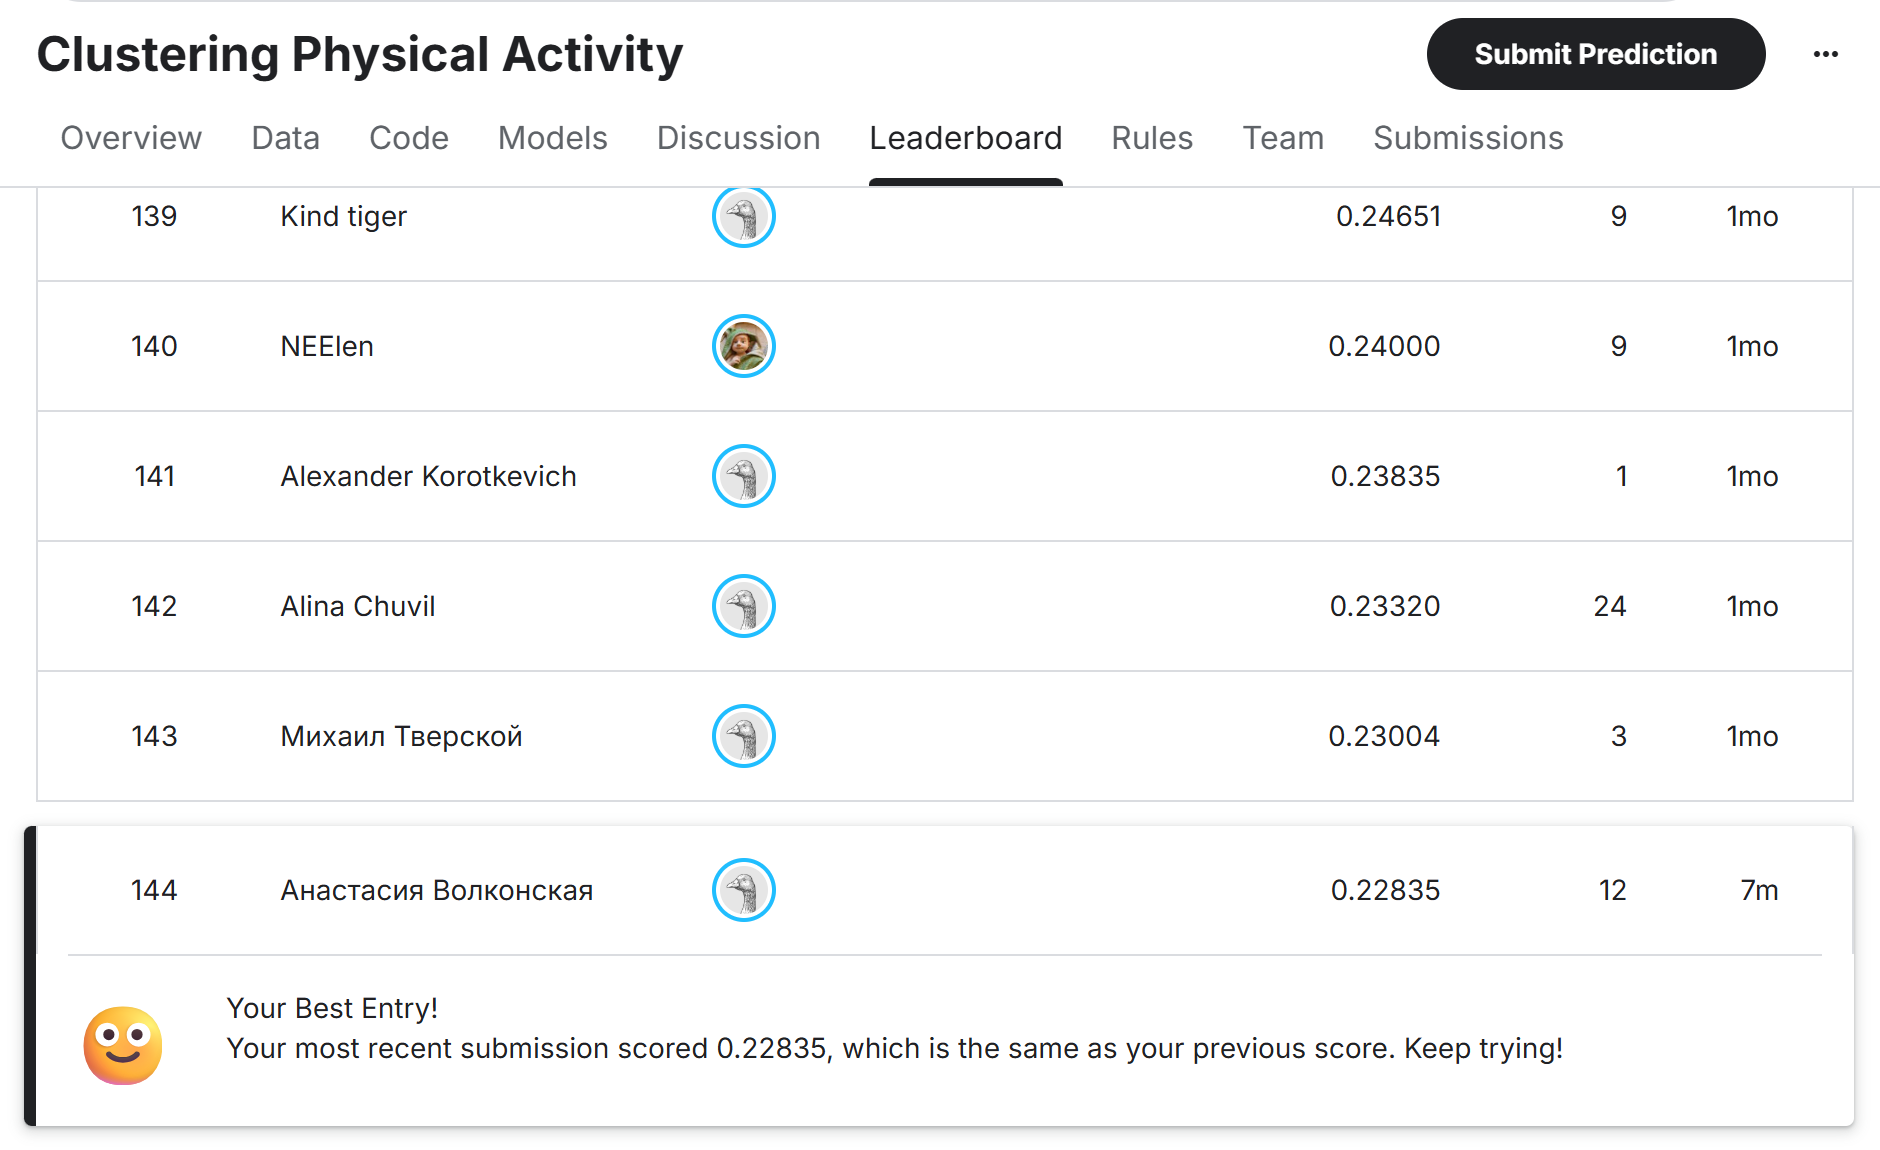

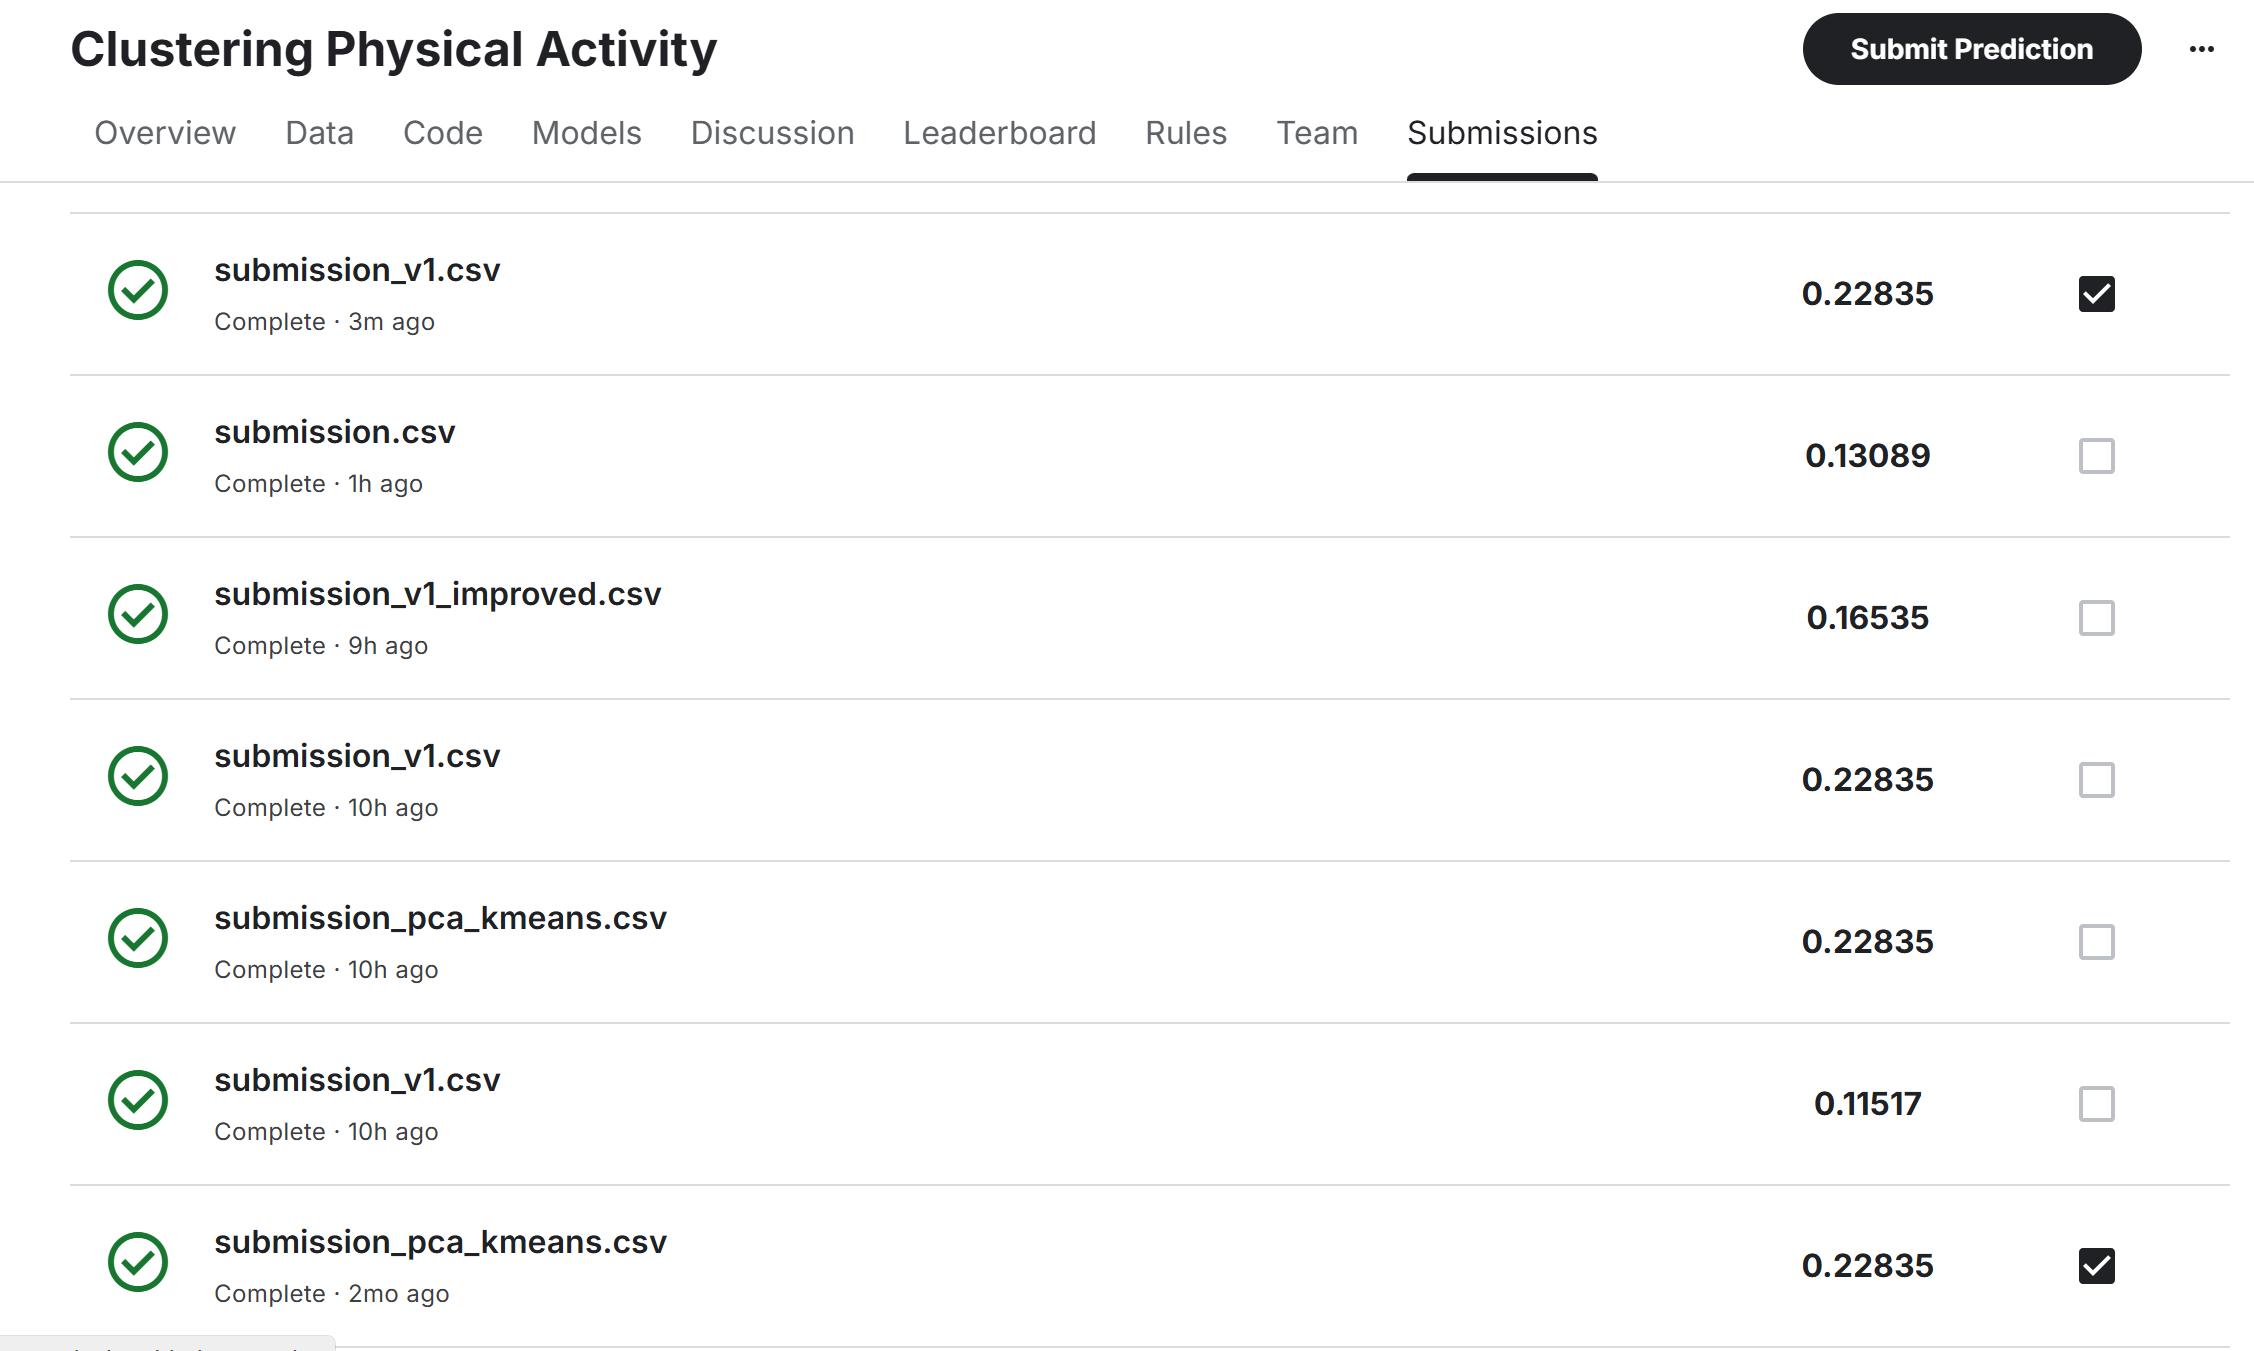